## Finalllll

In [33]:
# ============================================================
# 03f_dynamic_survival_transformer.ipynb
# Dynamic Survival Transformer (DST)
#
# Key design:
#   - Growing window from hour 1 (full admission history)
#   - DeepHit loss — handles censoring correctly
#   - Output: survival curve S(t) → risk = 1 - S(h+12)
#   - Winsorised features to fix SpO2 dominance
#   - GradientSHAP per patient per hour for UI explainability
#   - Replaces RollingTransformer as the deployed model
# ============================================================

In [34]:
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from pathlib import Path
import warnings
import joblib
import json
warnings.filterwarnings('ignore')

import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

PROJECT_ROOT = Path('C:/Users/20220505/Desktop/AI-sepsis')
sys.path.append(str(PROJECT_ROOT / 'src'))
OUTPUT_DIR = Path('C:/Users/20220505/Desktop/output path')

# ── Constants ─────────────────────────────────────────────────
MAX_HOURS      = 200
HERO_HORIZON_H = 12
NUM_BINS       = 48
BATCH_SIZE     = 256
EPOCHS         = 50
PATIENCE       = 10

time_cuts = np.linspace(0, MAX_HOURS, NUM_BINS + 1)[1:]

ALERT_THRESHOLDS = {
    'no_alert'  : (0.00, 0.50),
    'high_risk' : (0.50, 0.70),
    'critical'  : (0.70, 1.00),
}

def get_alert_tier(score):
    if score >= 0.70: return 'critical'
    elif score >= 0.50: return 'high_risk'
    else: return 'no_alert'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {device}')
print(f'PyTorch  : {torch.__version__}')

# ── Load metadata ─────────────────────────────────────────────
with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_cols = f.read().splitlines()

stay_ids_order = pd.read_csv(str(OUTPUT_DIR / 'stay_ids_order.csv')).squeeze().tolist()
stay_to_idx    = {sid: i for i, sid in enumerate(stay_ids_order)}

print(f'Rich features   : {len(rich_feature_names)}')
print(f'Static features : {len(feature_cols)}')
print(f'Stays           : {len(stay_ids_order):,}')
print('Setup complete ✓')

Device   : cuda
PyTorch  : 2.5.1+cu121
Rich features   : 25
Static features : 127
Stays           : 74,550
Setup complete ✓


In [35]:
# ── Load all data ─────────────────────────────────────────────
print('Loading data...')

# Cohort
cohort = pd.read_csv(str(OUTPUT_DIR / 'icu_cohort (1).csv'))
cohort['intime']  = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])
print(f'  Cohort         : {cohort.shape}')

# Hourly labels
hourly_labels = pd.read_csv(str(OUTPUT_DIR / 'hourly_labels.csv'))
print(f'  Hourly labels  : {hourly_labels.shape}')

# Splits
split_df = pd.read_csv(str(OUTPUT_DIR / 'subject_splits.csv'))
print(f'  Splits         : {split_df["split"].value_counts().to_dict()}')

# Engineered features (static)
all_features = pd.read_csv(str(OUTPUT_DIR / 'engineered_features.csv'))
print(f'  Features       : {all_features.shape}')

# Full hourly vitals array (growing window needs full history)
print('\nLoading X_rich_full.npy (1.49 GB)...')
X_rich_full = np.load(str(OUTPUT_DIR / 'X_rich_full.npy'))
print(f'  X_rich_full    : {X_rich_full.shape}')

# Stay order
stay_ids_order_csv = pd.read_csv(str(OUTPUT_DIR / 'stay_ids_order.csv')).squeeze().tolist()
stay_to_idx = {sid: i for i, sid in enumerate(stay_ids_order_csv)}

print('\nAll data loaded ✓')

Loading data...
  Cohort         : (94458, 27)
  Hourly labels  : (2618839, 8)
  Splits         : {'train': 38891, 'val': 8334, 'test': 8334}
  Features       : (89075, 128)

Loading X_rich_full.npy (1.49 GB)...
  X_rich_full    : (74550, 200, 25)

All data loaded ✓


## Building SUrvival Database

In [36]:
# ── Build survival datasets ───────────────────────────────────
print('Building survival datasets...')

# ── Add hour column if missing ────────────────────────────────
if 'hour' not in hourly_labels.columns:
    cohort_times = cohort[['stay_id', 'intime']].copy()
    hourly_labels = hourly_labels.merge(cohort_times, on='stay_id', how='left')
    hourly_labels['hour'] = (
        (pd.to_datetime(hourly_labels['abs_time']) - hourly_labels['intime'])
        .dt.total_seconds() / 3600
    ).astype(int)

# ── Sepsis onset per stay ─────────────────────────────────────
sepsis_onset = (
    hourly_labels[hourly_labels['label'] == 1]
    .groupby('stay_id')['hour'].min()
    .reset_index().rename(columns={'hour': 'sepsis_hour'})
)

# ── ICU stay duration ─────────────────────────────────────────
cohort_duration = cohort[['stay_id', 'intime', 'outtime']].copy()
cohort_duration['icu_hours'] = (
    (cohort_duration['outtime'] - cohort_duration['intime'])
    .dt.total_seconds() / 3600
).round(1).clip(lower=1)

# ── Full survival_df (all sepsis) ─────────────────────────────
survival_df = (
    pd.DataFrame({'stay_id': stay_ids_order})
    .merge(sepsis_onset,                              on='stay_id', how='left')
    .merge(cohort_duration[['stay_id', 'icu_hours']], on='stay_id', how='left')
    .merge(cohort[['stay_id', 'subject_id']],         on='stay_id', how='left')
    .merge(split_df,                                  on='subject_id', how='left')
    .merge(all_features,                              on='stay_id', how='left')
)
survival_df['event']    = survival_df['sepsis_hour'].notna().astype(int)
survival_df['duration'] = np.where(
    survival_df['event'] == 1,
    survival_df['sepsis_hour'],
    survival_df['icu_hours']
).clip(1)
survival_df = survival_df.dropna(subset=['duration', 'split'])
survival_df['duration'] = survival_df['duration'].astype(float)
survival_df['event']    = survival_df['event'].astype(int)

# ── Incident sepsis (onset > 4h) ──────────────────────────────
EXCLUSION_WINDOW  = 4
incident_sepsis   = survival_df[
    (survival_df['event'] == 1) & (survival_df['duration'] > EXCLUSION_WINDOW)
]
no_sepsis         = survival_df[survival_df['event'] == 0]
survival_incident = pd.concat([incident_sepsis, no_sepsis]).reset_index(drop=True)
survival_incident['event'] = survival_incident['event'].astype(int)

print(f'survival_df      : {len(survival_df):,} stays | '
      f'{survival_df["event"].sum():,} events '
      f'({survival_df["event"].mean():.3%})')
print(f'survival_incident: {len(survival_incident):,} stays | '
      f'{survival_incident["event"].sum():,} events '
      f'({survival_incident["event"].mean():.3%})')

# ── Train / val / test splits ─────────────────────────────────
train_all = survival_incident[survival_incident['split'] == 'train']
val_all   = survival_incident[survival_incident['split'] == 'val']
test_all  = survival_incident[survival_incident['split'] == 'test']

print(f'\nAll Sepsis splits:')
print(f'  Train : {len(train_all):,} | Val : {len(val_all):,} | Test : {len(test_all):,}')
print('\nSurvival datasets built ✓')

Building survival datasets...
survival_df      : 74,550 stays | 26,643 events (35.738%)
survival_incident: 52,234 stays | 4,327 events (8.284%)

All Sepsis splits:
  Train : 36,499 | Val : 7,848 | Test : 7,887

Survival datasets built ✓


In [37]:
# ── Cell 4: Winsorise static features to fix SpO2 dominance ──
print('Computing winsorisation bounds...')

# Use training set only to fit bounds
train_ids     = set(train_all['stay_id'].tolist())
train_features= all_features[all_features['stay_id'].isin(train_ids)]
feat_matrix   = train_features[feature_cols].values.astype(np.float32)

# Compute 1st and 99th percentile bounds per feature
WINSOR_LO = 1.0
WINSOR_HI = 99.0
lo_bounds = np.nanpercentile(feat_matrix, WINSOR_LO, axis=0)
hi_bounds = np.nanpercentile(feat_matrix, WINSOR_HI, axis=0)

# Save bounds for inference and UI
np.save(str(OUTPUT_DIR / 'dst_winsor_lo.npy'), lo_bounds)
np.save(str(OUTPUT_DIR / 'dst_winsor_hi.npy'), hi_bounds)
print(f'  Saved winsorisation bounds ✓')

# Check SpO2 features specifically
spo2_indices = [i for i, f in enumerate(feature_cols) if 'spo2' in f.lower()]
print(f'\nSpO2 feature bounds (before vs after winsorisation):')
print(f"{'Feature':<30} {'P1':>8} {'P99':>8}")
print('-' * 50)
for i in spo2_indices:
    print(f'  {feature_cols[i]:<28} {lo_bounds[i]:>8.3f} {hi_bounds[i]:>8.3f}')

# Build winsorised static feature matrix for all stays
print('\nBuilding winsorised static features...')
feat_all    = all_features.set_index('stay_id')[feature_cols].fillna(0)
X_static_raw= np.zeros((len(stay_ids_order), len(feature_cols)), dtype=np.float32)
for i, sid in enumerate(stay_ids_order):
    if sid in feat_all.index:
        X_static_raw[i] = feat_all.loc[sid].values.astype(np.float32)

# Apply winsorisation
X_static_winsor = np.clip(X_static_raw, lo_bounds, hi_bounds)

# Fit scaler on winsorised training features
from sklearn.preprocessing import StandardScaler
train_indices   = [stay_to_idx[sid] for sid in train_all['stay_id']
                   if sid in stay_to_idx]
scaler_dst      = StandardScaler()
scaler_dst.fit(X_static_winsor[train_indices])
X_static_scaled = scaler_dst.transform(X_static_winsor).astype(np.float32)
X_static_tensor = torch.tensor(X_static_scaled, dtype=torch.float32)

joblib.dump(scaler_dst, str(OUTPUT_DIR / 'dst_scaler.pkl'))
print(f'  X_static_scaled : {X_static_scaled.shape}')
print(f'  Scaler saved    : dst_scaler.pkl ✓')

# Also winsorise vital sequences (X_rich_full)
print('\nComputing vital sequence winsorisation bounds...')
# Use first 24h of training stays to fit vital bounds
vital_samples = []
for sid in list(train_ids)[:5000]:
    if sid in stay_to_idx:
        idx = stay_to_idx[sid]
        vital_samples.append(X_rich_full[idx, :24, :])
vital_samples = np.concatenate(vital_samples, axis=0)

vital_lo = np.nanpercentile(vital_samples, WINSOR_LO, axis=0)
vital_hi = np.nanpercentile(vital_samples, WINSOR_HI, axis=0)
np.save(str(OUTPUT_DIR / 'dst_vital_winsor_lo.npy'), vital_lo)
np.save(str(OUTPUT_DIR / 'dst_vital_winsor_hi.npy'), vital_hi)

print(f'  Vital bounds shape : {vital_lo.shape}')
print(f'  Saved vital winsorisation bounds ✓')

print('\nWinsorisation complete ✓')
print('SpO2 dominance will be reduced — extreme outlier values are now clipped')

Computing winsorisation bounds...
  Saved winsorisation bounds ✓

SpO2 feature bounds (before vs after winsorisation):
Feature                              P1      P99
--------------------------------------------------
  spo2_mean                      91.326   99.958
  spo2_std                        0.206    6.269
  spo2_min                       74.000   99.000
  spo2_max                       95.000  100.000
  spo2_last                      88.000  100.000
  spo2_slope                     -0.424    0.292
  spo2_missing_frac               0.000    0.333

Building winsorised static features...
  X_static_scaled : (74550, 127)
  Scaler saved    : dst_scaler.pkl ✓

Computing vital sequence winsorisation bounds...
  Vital bounds shape : (25,)
  Saved vital winsorisation bounds ✓

Winsorisation complete ✓
SpO2 dominance will be reduced — extreme outlier values are now clipped


In [38]:
# ── Cell 5: DST Dataset — growing window from hour 1 ──────────
print('Building DST Dataset...')

VITAL_MEDIANS = np.nanmedian(vital_samples, axis=0).astype(np.float32)

def impute_and_winsorise_sequence(x: np.ndarray) -> np.ndarray:
    """Forward fill, backfill, median impute, then winsorise vitals."""
    df = pd.DataFrame(x, columns=rich_feature_names)
    df = df.ffill().bfill()
    for i, col in enumerate(df.columns):
        df[col] = df[col].fillna(float(VITAL_MEDIANS[i]))
    arr = df.values.astype(np.float32)
    # Apply winsorisation to vital sequences
    arr = np.clip(arr, vital_lo, vital_hi)
    return arr

class DSTDataset(Dataset):
    """
    Dynamic Survival Transformer Dataset.
    Growing window: at training time, for each stay we sample
    a random observation hour h in [1, duration].
    The model sees ALL vitals from hour 0 to hour h.
    This teaches the model to work with any sequence length.
    """
    def __init__(self, survival_df, stay_to_idx,
                 X_rich_full, X_static_tensor,
                 feature_cols, cuts,
                 max_hours=MAX_HOURS,
                 training=True):
        self.samples  = []
        self.training = training
        skipped       = 0

        for _, row in survival_df.iterrows():
            stay_id  = row['stay_id']
            if stay_id not in stay_to_idx:
                skipped += 1
                continue
            idx      = stay_to_idx[stay_id]
            duration = float(min(row['duration'], max_hours))
            event    = int(row['event'])

            # Bin index for DeepHit loss
            bin_idx = min(
                int(np.searchsorted(cuts, duration, side='right')),
                len(cuts) - 1
            )

            # For training: store full sequence, sample hour at __getitem__
            # For val/test: use full sequence up to duration
            max_seq = min(int(duration), max_hours)
            if max_seq < 1:
                skipped += 1
                continue

            x_seq    = impute_and_winsorise_sequence(
                X_rich_full[idx, :max_seq, :]
            )
            x_static = X_static_tensor[idx]

            self.samples.append({
                'x_seq'   : x_seq,         # full sequence numpy array
                'x_static': x_static,      # tensor
                'bin_idx' : bin_idx,
                'event'   : event,
                'duration': duration,
                'max_seq' : max_seq,
            })

        print(f'  Built {len(self.samples):,} samples ({skipped:,} skipped)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        if self.training:
            # Sample a random observation horizon h in [1, max_seq]
            h     = np.random.randint(1, s['max_seq'] + 1)
            x_seq = torch.tensor(s['x_seq'][:h], dtype=torch.float32)
            length= h
        else:
            # Val/test: use full sequence
            x_seq  = torch.tensor(s['x_seq'], dtype=torch.float32)
            length = s['max_seq']
        return {
            'x_seq'   : x_seq,
            'x_static': s['x_static'],
            'bin_idx' : torch.tensor(s['bin_idx'],  dtype=torch.long),
            'event'   : torch.tensor(s['event'],    dtype=torch.long),
            'duration': torch.tensor(s['duration'], dtype=torch.float32),
            'length'  : torch.tensor(length,        dtype=torch.long),
        }


def collate_dst(batch):
    x_seqs    = [s['x_seq']    for s in batch]
    x_statics = torch.stack([s['x_static'] for s in batch])
    bin_idxs  = torch.stack([s['bin_idx']  for s in batch])
    events    = torch.stack([s['event']    for s in batch])
    durations = torch.stack([s['duration'] for s in batch])
    lengths   = torch.stack([s['length']   for s in batch])
    # Pad sequences to max length in batch
    max_len   = max(s.shape[0] for s in x_seqs)
    n_feat    = x_seqs[0].shape[1]
    x_padded  = torch.zeros(len(x_seqs), max_len, n_feat)
    for i, seq in enumerate(x_seqs):
        x_padded[i, :seq.shape[0], :] = seq
    return x_padded, x_statics, lengths, bin_idxs, events, durations


# ── Build datasets ────────────────────────────────────────────
print('\nBuilding train dataset (training=True — random horizon sampling)...')
train_ds = DSTDataset(train_all, stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=True)

print('Building val dataset...')
val_ds   = DSTDataset(val_all,   stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=False)

print('Building test dataset...')
test_ds  = DSTDataset(test_all,  stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_dst, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_dst, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_dst, num_workers=0)

print(f'\nTrain batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')
print(f'Test batches  : {len(test_loader):,}')
print('\nDataLoaders ready ✓')

Building DST Dataset...

Building train dataset (training=True — random horizon sampling)...


KeyboardInterrupt: 

In [ ]:
# ── Build survival datasets ───────────────────────────────────
print('Building survival datasets...')

# ── Add hour column if missing ────────────────────────────────
if 'hour' not in hourly_labels.columns:
    cohort_times = cohort[['stay_id', 'intime']].copy()
    hourly_labels = hourly_labels.merge(cohort_times, on='stay_id', how='left')
    hourly_labels['hour'] = (
        (pd.to_datetime(hourly_labels['abs_time']) - hourly_labels['intime'])
        .dt.total_seconds() / 3600
    ).astype(int)

# ── Sepsis onset per stay ─────────────────────────────────────
sepsis_onset = (
    hourly_labels[hourly_labels['label'] == 1]
    .groupby('stay_id')['hour'].min()
    .reset_index().rename(columns={'hour': 'sepsis_hour'})
)

# ── ICU stay duration ─────────────────────────────────────────
cohort_duration = cohort[['stay_id', 'intime', 'outtime']].copy()
cohort_duration['icu_hours'] = (
    (cohort_duration['outtime'] - cohort_duration['intime'])
    .dt.total_seconds() / 3600
).round(1).clip(lower=1)

# ── Full survival_df (all sepsis) ─────────────────────────────
survival_df = (
    pd.DataFrame({'stay_id': stay_ids_order})
    .merge(sepsis_onset,                              on='stay_id', how='left')
    .merge(cohort_duration[['stay_id', 'icu_hours']], on='stay_id', how='left')
    .merge(cohort[['stay_id', 'subject_id']],         on='stay_id', how='left')
    .merge(split_df,                                  on='subject_id', how='left')
    .merge(all_features,                              on='stay_id', how='left')
)
survival_df['event']    = survival_df['sepsis_hour'].notna().astype(int)
survival_df['duration'] = np.where(
    survival_df['event'] == 1,
    survival_df['sepsis_hour'],
    survival_df['icu_hours']
).clip(1)
survival_df = survival_df.dropna(subset=['duration', 'split'])
survival_df['duration'] = survival_df['duration'].astype(float)
survival_df['event']    = survival_df['event'].astype(int)

# ── Incident sepsis only (onset > 4h) — USED FOR TRAINING ─────
EXCLUSION_WINDOW  = 4
incident_sepsis   = survival_df[
    (survival_df['event'] == 1) & (survival_df['duration'] > EXCLUSION_WINDOW)
]
no_sepsis         = survival_df[survival_df['event'] == 0]
survival_incident = pd.concat([incident_sepsis, no_sepsis]).reset_index(drop=True)
survival_incident['event'] = survival_incident['event'].astype(int)

# ── Train / val / test splits — INCIDENT ONLY ─────────────────
train_all = survival_incident[survival_incident['split'] == 'train']
val_all   = survival_incident[survival_incident['split'] == 'val']
test_all  = survival_incident[survival_incident['split'] == 'test']

print(f'survival_df      : {len(survival_df):,} stays | '
      f'{survival_df["event"].sum():,} events '
      f'({survival_df["event"].mean():.3%})')
print(f'survival_incident: {len(survival_incident):,} stays | '
      f'{survival_incident["event"].sum():,} events '
      f'({survival_incident["event"].mean():.3%})')
print(f'\nIncident splits (used for training):')
print(f'  Train : {len(train_all):,} | Val : {len(val_all):,} | Test : {len(test_all):,}')
print('\nSurvival datasets built ✓')

Building survival datasets...
survival_df      : 74,550 stays | 26,643 events (35.738%)
survival_incident: 52,234 stays | 4,327 events (8.284%)

Incident splits (used for training):
  Train : 36,499 | Val : 7,848 | Test : 7,887

Survival datasets built ✓


In [ ]:
# ── Rebuild datasets with incident-only splits ────────────────
print('Building Dataset with incident splits...')

print('Building train dataset...')
train_ds = DSTDataset(train_all, stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=True)

print('Building val dataset...')
val_ds   = DSTDataset(val_all,   stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=False)

print('Building test dataset...')
test_ds  = DSTDataset(test_all,  stay_to_idx, X_rich_full,
                      X_static_tensor, feature_cols, time_cuts,
                      training=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_dst, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_dst, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_dst, num_workers=0)

print(f'\nTrain batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')
print(f'Test batches  : {len(test_loader):,}')
print('\nDataLoaders ready ✓')

Building Dataset with incident splits...
Building train dataset...
  Built 36,499 samples (0 skipped)
Building val dataset...
  Built 7,848 samples (0 skipped)
Building test dataset...
  Built 7,887 samples (0 skipped)

Train batches : 143
Val batches   : 31
Test batches  : 31

DataLoaders ready ✓


## DSTA Architecture

In [ ]:
# ── Cell 6: Dynamic Survival Transformer Architecture ─────────

class DynamicSurvivalTransformer(nn.Module):
    """
    Dynamic Survival Transformer (DST)

    Key design decisions:
    - Accepts variable-length sequences (1h to 200h) via padding + masking
    - CLS token aggregates the full sequence context
    - Pre-LN (norm_first=True) for training stability
    - Static features encoded separately then fused
    - Output: softmax PMF over NUM_BINS discrete time bins
    - Loss: DeepHit — correctly handles censored observations
    - Risk score = 1 - S(h + 12h) derived from survival curve
    """
    def __init__(self,
                 vital_dim     = 25,
                 static_dim    = 127,
                 d_model       = 256,
                 nhead         = 8,
                 n_layers      = 3,
                 static_hidden = 128,
                 fusion_hidden = 256,
                 num_bins      = NUM_BINS,
                 dropout       = 0.2,
                 max_seq_len   = 200):
        super().__init__()
        self.d_model  = d_model
        self.num_bins = num_bins

        # ── Vital sequence encoder ────────────────────────────
        self.vital_proj = nn.Linear(vital_dim, d_model)
        self.cls_token  = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.pos_emb    = nn.Embedding(max_seq_len + 1, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = d_model * 4,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,   # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)

        # ── Static feature encoder ────────────────────────────
        self.static_enc = nn.Sequential(
            nn.Linear(static_dim, static_hidden * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(static_hidden * 2, static_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Fusion head ───────────────────────────────────────
        self.fusion = nn.Sequential(
            nn.LayerNorm(d_model + static_hidden),
            nn.Linear(d_model + static_hidden, fusion_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, fusion_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden // 2, num_bins),
        )

    def forward(self, x_seq, x_static, lengths):
        B, T, _ = x_seq.shape

        # Project vitals to d_model
        x   = self.vital_proj(x_seq)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        # Positional embeddings
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0)
        x   = x + self.pos_emb(pos)

        # Padding mask — True = ignore position
        mask = torch.ones(B, T + 1, dtype=torch.bool, device=x.device)
        mask[:, 0] = False  # CLS always attended to
        for i, l in enumerate(lengths):
            mask[i, 1:l.item() + 1] = False

        # Transformer
        out     = self.transformer(x, src_key_padding_mask=mask)
        cls_out = out[:, 0, :]  # CLS token output

        # Static encoder
        s_out = self.static_enc(x_static)

        # Fuse and predict PMF
        fused = torch.cat([cls_out, s_out], dim=1)
        return torch.softmax(self.fusion(fused), dim=1)


# ── Instantiate model ─────────────────────────────────────────
model = DynamicSurvivalTransformer(
    vital_dim     = len(rich_feature_names),
    static_dim    = len(feature_cols),
    d_model       = 256,
    nhead         = 8,
    n_layers      = 3,
    static_hidden = 128,
    fusion_hidden = 256,
    num_bins      = NUM_BINS,
    dropout       = 0.2,
    max_seq_len   = MAX_HOURS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'DynamicSurvivalTransformer')
print(f'  Parameters : {n_params:,}')
print(f'  d_model    : 256  (vs 128 in TransformerSurvival)')
print(f'  n_heads    : 8    (vs 4)')
print(f'  n_layers   : 3    (vs 2)')
print(f'  max_seq    : 200h (vs 24h)')
print(f'  Device     : {device}')

# ── Verify forward pass ───────────────────────────────────────
model.eval()
with torch.no_grad():
    dummy_seq    = torch.randn(4, 50, len(rich_feature_names)).to(device)
    dummy_static = torch.randn(4, len(feature_cols)).to(device)
    dummy_lens   = torch.tensor([10, 25, 50, 30]).to(device)
    out          = model(dummy_seq, dummy_static, dummy_lens)
    assert out.shape == (4, NUM_BINS), f'Unexpected output shape: {out.shape}'
    assert abs(out.sum(dim=1).mean().item() - 1.0) < 1e-4, 'PMF does not sum to 1'
print(f'\nForward pass verified ✓')
print(f'  Input  : (4, 50, 25) sequence + (4, 127) static')
print(f'  Output : {out.shape}  — PMF sums to 1.0 ✓')
print('\nArchitecture ready ✓')

DynamicSurvivalTransformer
  Parameters : 2,631,728
  d_model    : 256  (vs 128 in TransformerSurvival)
  n_heads    : 8    (vs 4)
  n_layers   : 3    (vs 2)
  max_seq    : 200h (vs 24h)
  Device     : cuda

Forward pass verified ✓
  Input  : (4, 50, 25) sequence + (4, 127) static
  Output : torch.Size([4, 48])  — PMF sums to 1.0 ✓

Architecture ready ✓


## Loss and Helper Functions

In [ ]:
# ── Cell 7: Loss function & evaluation helpers ────────────────

# ── Stable DeepHit loss ───────────────────────────────────────
def deephit_loss_stable(pmf, bin_idx, event, alpha=0.2, sigma=0.1):
    """
    DeepHit loss — handles censored observations correctly.
    Censored patients (event=0) contribute only to ranking loss,
    not to the NLL term. This is the key difference from BCE.
    """
    eps        = 1e-7
    batch_size = pmf.size(0)
    pmf_safe   = pmf.clamp(eps, 1 - eps)

    # ── NLL — only for uncensored (event=1) cases ─────────────
    nll_loss = torch.tensor(0.0, device=pmf.device)
    if event.sum() > 0:
        ev_mask  = event == 1
        ev_bins  = bin_idx[ev_mask]
        nll_loss = -torch.log(pmf_safe[ev_mask, ev_bins]).mean()

    # ── Ranking loss — all cases contribute ───────────────────
    cif       = torch.cumsum(pmf_safe, dim=1).clamp(0, 1)
    t_i       = bin_idx.float()
    t_j       = bin_idx.float().unsqueeze(0)
    indicator = (
        (t_i.unsqueeze(1) < t_j) &
        (event.unsqueeze(1) == 1)
    ).float()
    cif_i     = cif[torch.arange(batch_size), bin_idx]
    diff      = cif_i.unsqueeze(1) - cif_i.unsqueeze(0)
    rank_loss = (
        indicator * torch.exp(-diff / sigma)
    ).sum() / (indicator.sum() + eps)

    return alpha * nll_loss + (1 - alpha) * rank_loss


# ── Predict survival curves ───────────────────────────────────
def predict_survival(model, loader, device, cuts):
    model.eval()
    all_pmf, all_dur, all_event = [], [], []
    with torch.no_grad():
        for x_seq, x_static, lengths, bin_idx, event, duration in loader:
            pmf = model(
                x_seq.to(device),
                x_static.to(device),
                lengths.to(device)
            ).cpu().numpy()
            all_pmf.append(pmf)
            all_dur.append(duration.numpy())
            all_event.append(event.numpy())
    pmf_all   = np.concatenate(all_pmf,   axis=0)
    dur_all   = np.concatenate(all_dur,   axis=0)
    event_all = np.concatenate(all_event, axis=0)
    surv_all  = 1 - np.cumsum(pmf_all, axis=1)
    return surv_all, dur_all, event_all


# ── C-index ───────────────────────────────────────────────────
from pycox.evaluation import EvalSurv

def compute_cindex(surv, durations, events, cuts):
    surv_df = pd.DataFrame(surv.T, index=cuts)
    ev      = EvalSurv(surv_df, durations, events, censor_surv='km')
    return ev.concordance_td()


# ── IBS ───────────────────────────────────────────────────────
def compute_ibs(surv, durations, events, cuts):
    surv_df     = pd.DataFrame(surv.T, index=cuts)
    ev          = EvalSurv(surv_df, durations, events, censor_surv='km')
    event_times = durations[events == 1]
    t_min       = np.percentile(event_times, 5)
    t_max       = np.percentile(event_times, 95)
    return ev.integrated_brier_score(np.linspace(t_min, t_max, 100))


# ── Risk score from survival curve ───────────────────────────
def survival_to_risk(surv, horizon_h, cuts):
    """Extract 1 - S(h + horizon) as risk score."""
    bin_H = int(np.clip(
        np.searchsorted(cuts, horizon_h, 'right'), 0, len(cuts) - 1
    ))
    return (1 - surv[:, bin_H]).clip(0, 1)


# ── Horizon AUROC / AUPRC ─────────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

HORIZONS = [6, 12, 24]

def horizon_metrics(surv, durations, events, cuts, horizons=HORIZONS):
    results = {}
    for H in horizons:
        bin_H   = int(np.clip(
            np.searchsorted(cuts, H, 'right'), 0, len(cuts) - 1
        ))
        y_true  = ((events == 1) & (durations <= H)).astype(int)
        y_score = (1 - surv[:, bin_H]).clip(0, 1)
        n_pos   = int(y_true.sum())
        if n_pos < 5 or (len(y_true) - n_pos) < 5:
            results[H] = {
                'auroc': float('nan'), 'auprc': float('nan'),
                'n_pos': n_pos, 'n_total': len(y_true)
            }
        else:
            results[H] = {
                'auroc': roc_auc_score(y_true, y_score),
                'auprc': average_precision_score(y_true, y_score),
                'n_pos': n_pos, 'n_total': len(y_true)
            }
    return results


# ── Calibration ───────────────────────────────────────────────
from sklearn.isotonic import IsotonicRegression

def fit_calibrators(surv_val, dur_val, evt_val, cuts, num_bins):
    """Fit isotonic regression calibrators on validation set."""
    calibrators = {}
    for t_idx in np.arange(0, num_bins, 4):
        true_label = ((evt_val == 1) & (dur_val <= cuts[t_idx])).astype(float)
        pred_cif   = (1 - surv_val[:, t_idx]).clip(0, 1)
        if true_label.sum() > 0 and (1 - true_label).sum() > 0:
            iso = IsotonicRegression(out_of_bounds='clip')
            iso.fit(pred_cif, true_label)
            calibrators[t_idx] = iso
    return calibrators

def apply_calibration(surv, calibrators, num_bins):
    """Apply isotonic calibration to survival curves."""
    surv_cal      = surv.copy()
    cal_t_indices = sorted(calibrators.keys())
    for t_idx in cal_t_indices:
        iso      = calibrators[t_idx]
        cif_raw  = (1 - surv_cal[:, t_idx]).clip(0, 1)
        cif_cal  = iso.predict(cif_raw).clip(0, 1)
        surv_cal[:, t_idx] = 1 - cif_cal
    # Interpolate between calibrated points
    x_known  = np.array(cal_t_indices)
    y_known  = surv_cal[:, cal_t_indices]
    for t in range(num_bins):
        if t not in calibrators:
            lo = max([k for k in cal_t_indices if k <= t], default=None)
            hi = min([k for k in cal_t_indices if k >= t], default=None)
            if lo is not None and hi is not None and lo != hi:
                w = (t - lo) / (hi - lo)
                surv_cal[:, t] = (1-w)*surv_cal[:, lo] + w*surv_cal[:, hi]
            elif lo is not None:
                surv_cal[:, t] = surv_cal[:, lo]
            elif hi is not None:
                surv_cal[:, t] = surv_cal[:, hi]
    # Enforce monotone decreasing
    for t in range(1, num_bins):
        surv_cal[:, t] = np.minimum(surv_cal[:, t], surv_cal[:, t-1])
    return surv_cal


print('Loss function   : DeepHit (stable) — censoring handled ✓')
print('Evaluation      : C-index, IBS, AUROC@6/12/24h ✓')
print('Calibration     : Isotonic regression ✓')
print('Helper functions defined ✓')

Loss function   : DeepHit (stable) — censoring handled ✓
Evaluation      : C-index, IBS, AUROC@6/12/24h ✓
Calibration     : Isotonic regression ✓
Helper functions defined ✓


## Training and Valid

In [ ]:
# ── Cell 8: Train DST ─────────────────────────────────────────
import time

optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-4, weight_decay=1e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

best_val   = np.inf
best_epoch = 0
patience_c = 0
history    = []

print('Training DynamicSurvivalTransformer...')
print('=' * 65)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | "
      f"{'LR':>8} | {'Time':>6}")
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── Train ────────────────────────────────────────────────
    model.train()
    tot = 0; cnt = 0
    for x_seq, x_static, lengths, bin_idx, event, duration in train_loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        lengths  = lengths.to(device)
        bin_idx  = bin_idx.to(device)
        event    = event.to(device)

        optimizer.zero_grad()
        pmf  = model(x_seq, x_static, lengths)
        loss = deephit_loss_stable(pmf, bin_idx, event)
        if torch.isnan(loss):
            continue
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item() * len(event)
        cnt += len(event)
    train_loss = tot / max(cnt, 1)

    # ── Validate ─────────────────────────────────────────────
    model.eval()
    tot = 0; cnt = 0
    with torch.no_grad():
        for x_seq, x_static, lengths, bin_idx, event, duration in val_loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            bin_idx  = bin_idx.to(device)
            event    = event.to(device)
            pmf  = model(x_seq, x_static, lengths)
            loss = deephit_loss_stable(pmf, bin_idx, event)
            if torch.isnan(loss):
                continue
            tot += loss.item() * len(event)
            cnt += len(event)
    val_loss = tot / max(cnt, 1)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    history.append({
        'epoch': epoch, 'train': train_loss,
        'val': val_loss, 'lr': lr_now
    })
    print(f'{epoch:>5} | {train_loss:>10.4f} | {val_loss:>9.4f} | '
          f'{lr_now:>8.6f} | {elapsed:>5.0f}s')

    scheduler.step(val_loss)

    # ── Early stopping ────────────────────────────────────────
    if val_loss < best_val:
        best_val   = val_loss
        best_epoch = epoch
        patience_c = 0
        torch.save(
            model.state_dict(),
            str(OUTPUT_DIR / 'dst_best.pt')
        )
    else:
        patience_c += 1
        if patience_c >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} '
                  f'(best={best_epoch}, val_loss={best_val:.4f})')
            break

pd.DataFrame(history).to_csv(
    str(OUTPUT_DIR / 'dst_training_history.csv'), index=False
)
print(f'\nBest val loss : {best_val:.4f} at epoch {best_epoch}')
print(f'Saved -> dst_best.pt ✓')
print(f'Saved -> dst_training_history.csv ✓')

Training DynamicSurvivalTransformer...
Epoch | Train Loss |  Val Loss |       LR |   Time
-----------------------------------------------------------------
    1 |    33.1816 |    0.1167 | 0.000100 |    18s
    2 |     1.5093 |    0.1133 | 0.000100 |    17s
    3 |     1.4115 |    0.1107 | 0.000100 |    16s
    4 |     1.3877 |    0.1132 | 0.000100 |    16s
    5 |     1.3924 |    0.1124 | 0.000100 |    16s
    6 |     1.3655 |    0.1102 | 0.000100 |    16s
    7 |     1.3466 |    0.1199 | 0.000100 |    16s
    8 |     1.3162 |    0.1136 | 0.000100 |    16s
    9 |     1.2996 |    0.1119 | 0.000100 |    17s
   10 |     1.2917 |    0.1161 | 0.000100 |    16s
   11 |     1.2915 |    0.1157 | 0.000100 |    16s
   12 |     1.2694 |    0.1123 | 0.000100 |    17s
   13 |     1.2592 |    0.1121 | 0.000050 |    17s
   14 |     1.2377 |    0.1100 | 0.000050 |    17s
   15 |     1.2408 |    0.1139 | 0.000050 |    17s
   16 |     1.2351 |    0.1098 | 0.000050 |    16s
   17 |     1.2346 |    0.10

In [ ]:
# ── Cell 9: Evaluate & Calibrate DST ─────────────────────────
print('Loading best weights...')
model.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'dst_best.pt'),
    map_location=device, weights_only=True
))
model.eval()

# ── Raw predictions on test set ───────────────────────────────
print('Predicting on test set...')
surv_test, dur_test, evt_test = predict_survival(
    model, test_loader, device, time_cuts
)

cindex_raw = compute_cindex(surv_test, dur_test, evt_test, time_cuts)
ibs_raw    = compute_ibs(surv_test, dur_test, evt_test, time_cuts)
print(f'\nRaw test results:')
print(f'  C-index : {cindex_raw:.4f}')
print(f'  IBS     : {ibs_raw:.4f}')

h_raw = horizon_metrics(surv_test, dur_test, evt_test, time_cuts)
print(f'\nAUROC at horizons (raw):')
for H in HORIZONS:
    r = h_raw[H]
    print(f'  @{H:>2}h — AUROC: {r["auroc"]:.4f}  '
          f'AUPRC: {r["auprc"]:.4f}  '
          f'(n_pos={r["n_pos"]:,}/{r["n_total"]:,})')

# ── Calibrate on validation set ───────────────────────────────
print('\nFitting calibrators on validation set...')
surv_val, dur_val, evt_val = predict_survival(
    model, val_loader, device, time_cuts
)
calibrators = fit_calibrators(
    surv_val, dur_val, evt_val, time_cuts, NUM_BINS
)
print(f'  Fitted {len(calibrators)} calibration points')

# Apply calibration to test set
surv_test_cal = apply_calibration(surv_test, calibrators, NUM_BINS)

cindex_cal = compute_cindex(surv_test_cal, dur_test, evt_test, time_cuts)
ibs_cal    = compute_ibs(surv_test_cal, dur_test, evt_test, time_cuts)
print(f'\nCalibrated test results:')
print(f'  C-index : {cindex_cal:.4f}')
print(f'  IBS     : {ibs_cal:.4f}')

h_cal = horizon_metrics(surv_test_cal, dur_test, evt_test, time_cuts)
print(f'\nAUROC at horizons (calibrated):')
for H in HORIZONS:
    r = h_cal[H]
    print(f'  @{H:>2}h — AUROC: {r["auroc"]:.4f}  '
          f'AUPRC: {r["auprc"]:.4f}  '
          f'(n_pos={r["n_pos"]:,}/{r["n_total"]:,})')

# ── Save all outputs ──────────────────────────────────────────
print('\nSaving outputs...')
np.save(str(OUTPUT_DIR / 'dst_surv_raw.npy'),   surv_test)
np.save(str(OUTPUT_DIR / 'dst_surv_cal.npy'),   surv_test_cal)
np.save(str(OUTPUT_DIR / 'dst_dur_test.npy'),   dur_test)
np.save(str(OUTPUT_DIR / 'dst_evt_test.npy'),   evt_test)
joblib.dump(calibrators, str(OUTPUT_DIR / 'dst_calibrators.pkl'))

print('  dst_surv_raw.npy       ✓')
print('  dst_surv_cal.npy       ✓')
print('  dst_dur_test.npy       ✓')
print('  dst_evt_test.npy       ✓')
print('  dst_calibrators.pkl    ✓')

# ── Summary ───────────────────────────────────────────────────
print(f'\n{"="*55}')
print(f'DST EVALUATION SUMMARY')
print(f'{"="*55}')
print(f'{"Metric":<20} {"Raw":>10} {"Calibrated":>12}')
print(f'{"-"*45}')
print(f'{"C-index":<20} {cindex_raw:>10.4f} {cindex_cal:>12.4f}')
print(f'{"IBS":<20} {ibs_raw:>10.4f} {ibs_cal:>12.4f}')
for H in HORIZONS:
    print(f'{"AUROC@"+str(H)+"h":<20} '
          f'{h_raw[H]["auroc"]:>10.4f} '
          f'{h_cal[H]["auroc"]:>12.4f}')
print(f'{"="*55}')

Loading best weights...
Predicting on test set...

Raw test results:
  C-index : 0.5974
  IBS     : 0.3915

AUROC at horizons (raw):
  @ 6h — AUROC: 0.9986  AUPRC: 0.9248  (n_pos=102/7,887)
  @12h — AUROC: 0.9977  AUPRC: 0.9700  (n_pos=293/7,887)
  @24h — AUROC: 0.9855  AUPRC: 0.9073  (n_pos=414/7,887)

Fitting calibrators on validation set...
  Fitted 11 calibration points

Calibrated test results:
  C-index : 0.9769
  IBS     : 0.0443

AUROC at horizons (calibrated):
  @ 6h — AUROC: 0.9880  AUPRC: 0.3593  (n_pos=102/7,887)
  @12h — AUROC: 0.9956  AUPRC: 0.9187  (n_pos=293/7,887)
  @24h — AUROC: 0.9852  AUPRC: 0.9029  (n_pos=414/7,887)

Saving outputs...
  dst_surv_raw.npy       ✓
  dst_surv_cal.npy       ✓
  dst_dur_test.npy       ✓
  dst_evt_test.npy       ✓
  dst_calibrators.pkl    ✓

DST EVALUATION SUMMARY
Metric                      Raw   Calibrated
---------------------------------------------
C-index                  0.5974       0.9769
IBS                      0.3915       0.0

In [ ]:
# Check onset distribution in test set
test_stays = survival_df[survival_df['split'] == 'test']
sepsis_test = test_stays[test_stays['event'] == 1]
print(f"Onset distribution in test set:")
print(f"  Onset <= 4h  : {(sepsis_test['duration'] <= 4).sum():,} "
      f"({(sepsis_test['duration'] <= 4).mean():.1%})")
print(f"  Onset <= 12h : {(sepsis_test['duration'] <= 12).sum():,} "
      f"({(sepsis_test['duration'] <= 12).mean():.1%})")
print(f"  Onset > 12h  : {(sepsis_test['duration'] > 12).sum():,} "
      f"({(sepsis_test['duration'] > 12).mean():.1%})")
print(f"  Onset > 24h  : {(sepsis_test['duration'] > 24).sum():,} "
      f"({(sepsis_test['duration'] > 24).mean():.1%})")

Onset distribution in test set:
  Onset <= 4h  : 3,356 (84.4%)
  Onset <= 12h : 3,649 (91.8%)
  Onset > 12h  : 327 (8.2%)
  Onset > 24h  : 206 (5.2%)


In [ ]:
# ── Correct evaluation — incident sepsis only ─────────────────
print('Correct evaluation — incident sepsis only (onset > 4h)\n')

# Filter test set to incident sepsis + no sepsis
test_inc_mask = (
    (evt_test == 0) |                    # censored patients
    (dur_test > EXCLUSION_WINDOW)        # incident sepsis only
)
surv_inc  = surv_test_cal[test_inc_mask]
dur_inc   = dur_test[test_inc_mask]
evt_inc   = evt_test[test_inc_mask]

print(f'Test set (incident only):')
print(f'  Total     : {len(dur_inc):,}')
print(f'  Events    : {int(evt_inc.sum()):,} ({evt_inc.mean():.3%})')
print(f'  Censored  : {int((evt_inc==0).sum()):,}')

cindex_inc = compute_cindex(surv_inc, dur_inc, evt_inc, time_cuts)
ibs_inc    = compute_ibs(surv_inc, dur_inc, evt_inc, time_cuts)
print(f'\n  C-index : {cindex_inc:.4f}')
print(f'  IBS     : {ibs_inc:.4f}')

h_inc = horizon_metrics(surv_inc, dur_inc, evt_inc, time_cuts)
print(f'\nAUROC at horizons (incident sepsis only):')
for H in HORIZONS:
    r = h_inc[H]
    print(f'  @{H:>2}h — AUROC: {r["auroc"]:.4f}  '
          f'AUPRC: {r["auprc"]:.4f}  '
          f'(n_pos={r["n_pos"]:,}/{r["n_total"]:,})')

# ── Also check onset distribution of remaining events ─────────
print(f'\nOnset distribution (incident only):')
inc_evt_dur = dur_inc[evt_inc == 1]
for threshold in [12, 24, 48, 96]:
    n = (inc_evt_dur <= threshold).sum()
    print(f'  Onset <= {threshold:>3}h : {n:,} ({n/len(inc_evt_dur):.1%})')

Correct evaluation — incident sepsis only (onset > 4h)

Test set (incident only):
  Total     : 7,887
  Events    : 620 (7.861%)
  Censored  : 7,267

  C-index : 0.8573
  IBS     : 0.0405

AUROC at horizons (incident sepsis only):
  @ 6h — AUROC: 0.9951  AUPRC: 0.7971  (n_pos=102/7,887)
  @12h — AUROC: 0.9954  AUPRC: 0.9052  (n_pos=293/7,887)
  @24h — AUROC: 0.9899  AUPRC: 0.9289  (n_pos=414/7,887)

Onset distribution (incident only):
  Onset <=  12h : 293 (47.3%)
  Onset <=  24h : 414 (66.8%)
  Onset <=  48h : 497 (80.2%)
  Onset <=  96h : 559 (90.2%)


In [ ]:
# ── Cell 10 (Optimized): DST Rolling Inference ────────────────
import time

print('Starting DST rolling inference (optimized)...')

model.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'dst_best.pt'),
    map_location=device, weights_only=True
))
model.eval()
calibrators = joblib.load(str(OUTPUT_DIR / 'dst_calibrators.pkl'))

onset_lookup = (
    hourly_labels[hourly_labels['label'] == 1]
    .groupby('stay_id')['hour'].min().to_dict()
)
max_hour_per_stay = hourly_labels.groupby('stay_id')['hour'].max().to_dict()
stay_split = (
    cohort[['stay_id', 'subject_id']]
    .merge(split_df, on='subject_id', how='left')
    .set_index('stay_id')['split'].to_dict()
)

def get_rolling_label(stay_id, hour, horizon=HERO_HORIZON_H):
    max_h = max_hour_per_stay.get(stay_id, 0)
    if hour > max_h: return -1
    onset = onset_lookup.get(stay_id, None)
    if onset is None: return 0
    if hour <= onset < hour + horizon: return 1
    return 0

bin_12h = int(np.clip(
    np.searchsorted(time_cuts, HERO_HORIZON_H, 'right'), 0, NUM_BINS - 1
))

# ── Pre-process all sequences upfront (vectorised) ────────────
print('Pre-processing all sequences...')
t0 = time.time()

# Apply winsorisation to entire X_rich_full at once (vectorised)
X_rich_proc = np.clip(X_rich_full, vital_lo, vital_hi).astype(np.float32)

# Forward-fill NaNs along time axis for each stay (vectorised)
# Convert NaN to 0 after ffill using pandas per stay would be slow
# Instead use a fast numpy approach: replace NaN with median
for f in range(X_rich_proc.shape[2]):
    nan_mask = np.isnan(X_rich_proc[:, :, f])
    X_rich_proc[:, :, f][nan_mask] = VITAL_MEDIANS[f]

print(f'  Pre-processing done in {time.time()-t0:.1f}s')
print(f'  X_rich_proc shape : {X_rich_proc.shape}')

# ── Build evaluation schedule ─────────────────────────────────
print('Building evaluation schedule...')
eval_pairs = []
for i, sid in enumerate(stay_ids_order):
    max_h = min(max_hour_per_stay.get(sid, 1), MAX_HOURS - 1)
    for h in range(1, max_h + 1):
        eval_pairs.append((i, sid, h))

total_pairs = len(eval_pairs)
print(f'Total stay-hours : {total_pairs:,}')

# ── Batch inference ───────────────────────────────────────────
INFER_BATCH = 512
results     = []
t_start     = time.time()

for batch_start in range(0, total_pairs, INFER_BATCH):
    batch     = eval_pairs[batch_start:batch_start + INFER_BATCH]
    x_seqs    = []
    x_statics = []
    lengths   = []
    meta      = []

    for stay_idx, stay_id, hour in batch:
        # Growing window — slice pre-processed array directly
        seq     = X_rich_proc[stay_idx, :hour, :]
        seq_len = len(seq)
        if seq_len == 0:
            continue
        x_seqs.append(torch.tensor(seq, dtype=torch.float32))
        x_statics.append(X_static_tensor[stay_idx])
        lengths.append(seq_len)
        meta.append((stay_id, hour, stay_split.get(stay_id, 'unknown')))

    if not x_seqs:
        continue

    # Pad sequences
    max_len  = max(s.shape[0] for s in x_seqs)
    x_padded = torch.zeros(len(x_seqs), max_len, len(rich_feature_names))
    for i, seq in enumerate(x_seqs):
        x_padded[i, :seq.shape[0], :] = seq

    x_padded   = x_padded.to(device)
    x_static_b = torch.stack(x_statics).to(device)
    lengths_t  = torch.tensor(lengths, dtype=torch.long).to(device)

    with torch.no_grad():
        pmf = model(x_padded, x_static_b, lengths_t).cpu().numpy()

    # Survival curve → calibrate → risk score
    surv     = 1 - np.cumsum(pmf, axis=1)
    surv_cal = apply_calibration(surv, calibrators, NUM_BINS)

    for i, (sid, hour, split) in enumerate(meta):
        risk  = float(np.clip(1 - surv_cal[i, bin_12h], 0.0, 1.0))
        tier  = get_alert_tier(risk)
        label = get_rolling_label(sid, hour)
        if label == -1:
            continue
        results.append({
            'stay_id'       : sid,
            'hour'          : hour,
            'risk_score'    : round(risk, 4),
            'alert_tier'    : tier,
            'true_label_12h': label,
            'split'         : split,
        })

    if (batch_start // INFER_BATCH) % 100 == 0 and batch_start > 0:
        elapsed = time.time() - t_start
        pct     = batch_start / total_pairs
        eta     = (elapsed / pct) * (1 - pct) / 60
        print(f'  {batch_start:>8,} / {total_pairs:,} '
              f'({pct:.1%}) | '
              f'elapsed={elapsed/60:.1f}min | '
              f'ETA={eta:.1f}min', end='\r')

print(f'\n\nInference complete.')
print(f'Total time : {(time.time()-t_start)/60:.1f} minutes')
print(f'Results    : {len(results):,} stay-hour predictions')

rolling_df = pd.DataFrame(results)
rolling_df.to_csv(str(OUTPUT_DIR / 'dst_rolling_predictions.csv'), index=False)
print(f'Saved -> dst_rolling_predictions.csv ✓')
print(rolling_df.head(10).to_string(index=False))

Starting DST rolling inference (optimized)...
Pre-processing all sequences...
  Pre-processing done in 7.4s
  X_rich_proc shape : (74550, 200, 25)
Building evaluation schedule...
Total stay-hours : 2,500,579
  2,457,600 / 2,500,579 (98.3%) | elapsed=6.0min | ETA=0.1min

Inference complete.
Total time : 6.1 minutes
Results    : 2,500,579 stay-hour predictions
Saved -> dst_rolling_predictions.csv ✓
 stay_id  hour  risk_score alert_tier  true_label_12h split
30000153     1         1.0   critical               0 train
30000153     2         1.0   critical               0 train
30000153     3         1.0   critical               0 train
30000153     4         1.0   critical               0 train
30000153     5         1.0   critical               0 train
30000153     6         1.0   critical               0 train
30000153     7         1.0   critical               0 train
30000153     8         1.0   critical               0 train
30000153     9         1.0   critical               0 train


In [ ]:
# Check stay 30000153
sid = 30000153
onset = onset_lookup.get(sid, 'No sepsis')
split = stay_split.get(sid, 'unknown')
print(f'stay_id={sid}  onset={onset}  split={split}')

# Check risk scores for an incident sepsis patient from test set
inc_test_stays = [
    sid for sid in test_all['stay_id'].tolist()
    if onset_lookup.get(sid, 0) > 4
]
print(f'\nChecking incident test patient...')
sample_sid = inc_test_stays[0]
sample_onset = onset_lookup.get(sample_sid)
sample = pd.DataFrame(results)[pd.DataFrame(results)['stay_id'] == sample_sid].sort_values('hour') if 'results' in dir() else None

# Load from saved file
rolling_df = pd.read_csv(str(OUTPUT_DIR / 'dst_rolling_predictions.csv'))
sample = rolling_df[rolling_df['stay_id'] == sample_sid].sort_values('hour')
print(f'stay_id={sample_sid}  onset={sample_onset}h')
print(sample[['hour','risk_score','alert_tier','true_label_12h']].head(20).to_string(index=False))

stay_id=30000153  onset=No sepsis  split=train

Checking incident test patient...
stay_id=30033179  onset=7h
 hour  risk_score alert_tier  true_label_12h
    1         1.0   critical               1
    2         1.0   critical               1
    3         1.0   critical               1
    4         1.0   critical               1
    5         1.0   critical               1
    6         1.0   critical               1
    7         1.0   critical               1
    8         1.0   critical               0
    9         1.0   critical               0
   10         1.0   critical               0
   11         1.0   critical               0
   12         1.0   critical               0


In [ ]:
# Check raw vs calibrated scores
print("Checking raw vs calibrated scores...")

# Load calibrators
import joblib
calibrators = joblib.load(str(OUTPUT_DIR / 'dst_calibrators.pkl'))
print(f'Calibrators: {len(calibrators)} time points')
print(f'Calibrator keys: {sorted(calibrators.keys())}')

# Check what the raw model outputs for a few patients
model.eval()
vital_lo = np.load(str(OUTPUT_DIR / 'dst_vital_winsor_lo.npy'))
vital_hi = np.load(str(OUTPUT_DIR / 'dst_vital_winsor_hi.npy'))
X_rich_proc = np.clip(X_rich_full, vital_lo, vital_hi).astype(np.float32)

# Test on sample patient
sid   = 30033179
idx   = stay_to_idx[sid]
onset = onset_lookup.get(sid)

print(f'\nRaw PMF outputs for stay {sid} (onset={onset}h):')
print(f'{"Hour":>5} {"Raw risk (bin_12h)":>20} {"Cal risk":>12}')
print('-'*40)

bin_12h = int(np.clip(np.searchsorted(time_cuts, 12, 'right'), 0, NUM_BINS-1))

for hour in [1, 3, 6, 9, 12, 15]:
    seq   = X_rich_proc[idx, :hour, :]
    seq_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    len_t = torch.tensor([hour], dtype=torch.long).to(device)
    x_s   = X_static_tensor[idx].unsqueeze(0).to(device)

    with torch.no_grad():
        pmf  = model(seq_t, x_s, len_t).cpu().numpy()
    surv     = 1 - np.cumsum(pmf, axis=1)
    raw_risk = float(1 - surv[0, bin_12h])

    # Apply calibration
    surv_cal = apply_calibration(surv, calibrators, NUM_BINS)
    cal_risk = float(np.clip(1 - surv_cal[0, bin_12h], 0, 1))

    print(f'{hour:>5} {raw_risk:>20.4f} {cal_risk:>12.4f}')

Checking raw vs calibrated scores...
Calibrators: 11 time points
Calibrator keys: [np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20), np.int64(24), np.int64(28), np.int64(32), np.int64(36), np.int64(40), np.int64(44)]

Raw PMF outputs for stay 30033179 (onset=7h):
 Hour   Raw risk (bin_12h)     Cal risk
----------------------------------------
    1               0.9942       1.0000
    3               0.9946       1.0000
    6               0.9928       1.0000
    9               0.9788       1.0000
   12               0.9273       1.0000
   15               0.8619       0.8519


In [ ]:
# ── Refit calibrators on new model's validation predictions ───
print('Refitting calibrators on new model validation set...')

model.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'dst_best.pt'),
    map_location=device, weights_only=True
))
model.eval()

# Get raw validation predictions
surv_val, dur_val, evt_val = predict_survival(
    model, val_loader, device, time_cuts
)
print(f'  Val predictions shape : {surv_val.shape}')
print(f'  Val raw risk@12h stats:')
bin_12h = int(np.clip(np.searchsorted(time_cuts, 12, 'right'), 0, NUM_BINS-1))
raw_risks = (1 - surv_val[:, bin_12h]).clip(0, 1)
print(f'    Mean   : {raw_risks.mean():.4f}')
print(f'    Median : {np.median(raw_risks):.4f}')
print(f'    Max    : {raw_risks.max():.4f}')
print(f'    Min    : {raw_risks.min():.4f}')

# Refit calibrators
calibrators = fit_calibrators(surv_val, dur_val, evt_val, time_cuts, NUM_BINS)
print(f'\n  Fitted {len(calibrators)} calibration points')

# Check calibration makes sense
print('\n  Calibration check — sample raw vs calibrated:')
surv_test, dur_test, evt_test = predict_survival(
    model, test_loader, device, time_cuts
)
surv_test_cal = apply_calibration(surv_test, calibrators, NUM_BINS)
raw_12h = (1 - surv_test[:, bin_12h]).clip(0, 1)
cal_12h = (1 - surv_test_cal[:, bin_12h]).clip(0, 1)
print(f'    Raw  — mean={raw_12h.mean():.4f}  median={np.median(raw_12h):.4f}  max={raw_12h.max():.4f}')
print(f'    Cal  — mean={cal_12h.mean():.4f}  median={np.median(cal_12h):.4f}  max={cal_12h.max():.4f}')

# Save updated calibrators
joblib.dump(calibrators, str(OUTPUT_DIR / 'dst_calibrators.pkl'))
np.save(str(OUTPUT_DIR / 'dst_surv_cal.npy'),   surv_test_cal)
np.save(str(OUTPUT_DIR / 'dst_surv_raw.npy'),   surv_test)
np.save(str(OUTPUT_DIR / 'dst_dur_test.npy'),   dur_test)
np.save(str(OUTPUT_DIR / 'dst_evt_test.npy'),   evt_test)
print('\nCalibrators refitted and saved ✓')

Refitting calibrators on new model validation set...
  Val predictions shape : (7848, 48)
  Val raw risk@12h stats:
    Mean   : 0.6004
    Median : 0.5989
    Max    : 0.9954
    Min    : 0.2938

  Fitted 11 calibration points

  Calibration check — sample raw vs calibrated:
    Raw  — mean=0.6008  median=0.5980  max=0.9956
    Cal  — mean=0.0529  median=0.0010  max=1.0000

Calibrators refitted and saved ✓


In [ ]:
# ── Rerun rolling inference with corrected calibrators ────────
import time

print("Starting DST rolling inference (corrected calibrators)...")

model.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'dst_best.pt'),
    map_location=device, weights_only=True
))
model.eval()
calibrators = joblib.load(str(OUTPUT_DIR / 'dst_calibrators.pkl'))

onset_lookup = (
    hourly_labels[hourly_labels['label'] == 1]
    .groupby('stay_id')['hour'].min().to_dict()
)
max_hour_per_stay = hourly_labels.groupby('stay_id')['hour'].max().to_dict()
stay_split = (
    cohort[['stay_id', 'subject_id']]
    .merge(split_df, on='subject_id', how='left')
    .set_index('stay_id')['split'].to_dict()
)

def get_rolling_label(stay_id, hour, horizon=HERO_HORIZON_H):
    max_h = max_hour_per_stay.get(stay_id, 0)
    if hour > max_h: return -1
    onset = onset_lookup.get(stay_id, None)
    if onset is None: return 0
    if hour <= onset < hour + horizon: return 1
    return 0

bin_12h = int(np.clip(
    np.searchsorted(time_cuts, HERO_HORIZON_H, 'right'), 0, NUM_BINS - 1
))

print('Pre-processing vital sequences...')
X_rich_proc = np.clip(X_rich_full, vital_lo, vital_hi).astype(np.float32)
for f in range(X_rich_proc.shape[2]):
    nan_mask = np.isnan(X_rich_proc[:, :, f])
    X_rich_proc[:, :, f][nan_mask] = 0.0
print(f'  X_rich_proc shape : {X_rich_proc.shape}')

print('Building evaluation schedule...')
eval_pairs = []
for i, sid in enumerate(stay_ids_order):
    max_h = min(max_hour_per_stay.get(sid, 1), MAX_HOURS - 1)
    for h in range(1, max_h + 1):
        eval_pairs.append((i, sid, h))

total_pairs = len(eval_pairs)
print(f'Total stay-hours : {total_pairs:,}')

INFER_BATCH = 512
results     = []
t_start     = time.time()

for batch_start in range(0, total_pairs, INFER_BATCH):
    batch     = eval_pairs[batch_start:batch_start + INFER_BATCH]
    x_seqs, x_statics, lengths, meta = [], [], [], []

    for stay_idx, stay_id, hour in batch:
        seq     = X_rich_proc[stay_idx, :hour, :]
        seq_len = len(seq)
        if seq_len == 0: continue
        x_seqs.append(torch.tensor(seq, dtype=torch.float32))
        x_statics.append(X_static_tensor[stay_idx])
        lengths.append(seq_len)
        meta.append((stay_id, hour, stay_split.get(stay_id, 'unknown')))

    if not x_seqs: continue

    max_len  = max(s.shape[0] for s in x_seqs)
    x_padded = torch.zeros(len(x_seqs), max_len, len(rich_feature_names))
    for i, seq in enumerate(x_seqs):
        x_padded[i, :seq.shape[0], :] = seq

    x_padded   = x_padded.to(device)
    x_static_b = torch.stack(x_statics).to(device)
    lengths_t  = torch.tensor(lengths, dtype=torch.long).to(device)

    with torch.no_grad():
        pmf = model(x_padded, x_static_b, lengths_t).cpu().numpy()

    surv     = 1 - np.cumsum(pmf, axis=1)
    surv_cal = apply_calibration(surv, calibrators, NUM_BINS)

    for i, (sid, hour, split) in enumerate(meta):
        risk_12h = float(np.clip(1 - surv_cal[i, bin_12h], 0.0, 1.0))
        tier     = get_alert_tier(risk_12h)
        label    = get_rolling_label(sid, hour)
        if label == -1: continue
        results.append({
            'stay_id'       : sid,
            'hour'          : hour,
            'risk_score'    : round(risk_12h, 4),
            'alert_tier'    : tier,
            'true_label_12h': label,
            'split'         : split,
        })

    if (batch_start // INFER_BATCH) % 100 == 0 and batch_start > 0:
        elapsed = time.time() - t_start
        pct     = batch_start / total_pairs
        eta     = (elapsed / max(pct, 1e-6)) * (1 - pct) / 60
        print(f'  {batch_start:>8,} / {total_pairs:,} '
              f'({pct:.1%}) | elapsed={elapsed/60:.1f}min | '
              f'ETA={eta:.1f}min', end='\r')

print(f'\n\nInference complete.')
print(f'Total time : {(time.time()-t_start)/60:.1f} minutes')
print(f'Results    : {len(results):,} stay-hour predictions')

rolling_df = pd.DataFrame(results)
rolling_df.to_csv(str(OUTPUT_DIR / 'dst_rolling_predictions.csv'), index=False)
rolling_df.to_csv(str(OUTPUT_DIR / 'rolling_predictions.csv'), index=False)
print(f'Saved -> dst_rolling_predictions.csv ✓')
print(f'Saved -> rolling_predictions.csv ✓')
print(rolling_df.head(10).to_string(index=False))

Starting DST rolling inference (corrected calibrators)...
Pre-processing vital sequences...
  X_rich_proc shape : (74550, 200, 25)
Building evaluation schedule...
Total stay-hours : 2,500,579
  2,457,600 / 2,500,579 (98.3%) | elapsed=5.9min | ETA=0.1min

Inference complete.
Total time : 6.0 minutes
Results    : 2,500,579 stay-hour predictions
Saved -> dst_rolling_predictions.csv ✓
Saved -> rolling_predictions.csv ✓
 stay_id  hour  risk_score alert_tier  true_label_12h split
30000153     1         1.0   critical               0 train
30000153     2         1.0   critical               0 train
30000153     3         1.0   critical               0 train
30000153     4         1.0   critical               0 train
30000153     5         1.0   critical               0 train
30000153     6         1.0   critical               0 train
30000153     7         1.0   critical               0 train
30000153     8         1.0   critical               0 train
30000153     9         1.0   critical    

In [ ]:
# Check overall risk score distribution after calibration fix
rolling_df = pd.read_csv(str(OUTPUT_DIR / 'rolling_predictions.csv'))

print("Risk score distribution:")
print(rolling_df['risk_score'].describe())

print(f"\nAlert tier distribution:")
for tier, count in rolling_df['alert_tier'].value_counts().items():
    print(f"  {tier:<12} : {count:>8,}  ({count/len(rolling_df):.2%})")

print(f"\nTest set AUROC:")
from sklearn.metrics import roc_auc_score, average_precision_score
test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
auroc = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
auprc = average_precision_score(test_roll['true_label_12h'], test_roll['risk_score'])
print(f"  AUROC : {auroc:.4f}")
print(f"  AUPRC : {auprc:.4f}")

# Check a known incident test patient
inc_test_sids = [
    sid for sid in test_roll['stay_id'].unique()
    if onset_lookup.get(sid, 0) > 4
]
sample_sid = inc_test_sids[0]
sample_onset = onset_lookup.get(sample_sid)
sample = test_roll[test_roll['stay_id'] == sample_sid].sort_values('hour')
print(f"\nSample incident patient: stay={sample_sid} onset={sample_onset}h")
print(sample[['hour','risk_score','alert_tier']].head(20).to_string(index=False))

Risk score distribution:
count    2.500579e+06
mean     1.981500e-01
std      3.702094e-01
min      0.000000e+00
25%      0.000000e+00
50%      2.500000e-03
75%      9.760000e-02
max      1.000000e+00
Name: risk_score, dtype: float64

Alert tier distribution:
  no_alert     : 2,008,494  (80.32%)
  critical     :  453,263  (18.13%)
  high_risk    :   38,822  (1.55%)

Test set AUROC:
  AUROC : 0.7827
  AUPRC : 0.0968

Sample incident patient: stay=30033179 onset=7h
 hour  risk_score alert_tier
    1         1.0   critical
    2         1.0   critical
    3         1.0   critical
    4         1.0   critical
    5         1.0   critical
    6         1.0   critical
    7         1.0   critical
    8         1.0   critical
    9         1.0   critical
   10         1.0   critical
   11         1.0   critical
   12         1.0   critical


In [ ]:
# Check patient with later onset
late_onset_sids = [
    sid for sid in test_roll['stay_id'].unique()
    if onset_lookup.get(sid, 0) > 24
]
print(f'Patients with onset > 24h in test set: {len(late_onset_sids)}')

for sid in late_onset_sids[:3]:
    onset = onset_lookup.get(sid)
    sample = test_roll[test_roll['stay_id'] == sid].sort_values('hour')
    print(f'\nstay={sid}  onset={onset}h')
    print(sample[['hour','risk_score','alert_tier']].to_string(index=False))

Patients with onset > 24h in test set: 206

stay=30130376  onset=69h
 hour  risk_score alert_tier
    1      0.9565   critical
    2      0.9565   critical
    3      0.9565   critical
    4      0.9565   critical
    5      0.9565   critical
    6      0.9565   critical
    7      0.9000   critical
    8      0.7600   critical
    9      0.5000  high_risk
   10      0.1217   no_alert
   11      0.0976   no_alert
   12      0.0882   no_alert
   13      0.0449   no_alert
   14      0.0400   no_alert
   15      0.0285   no_alert
   16      0.0285   no_alert
   17      0.0109   no_alert
   18      0.0109   no_alert
   19      0.0109   no_alert
   20      0.0109   no_alert
   21      0.0080   no_alert
   22      0.0080   no_alert
   23      0.0043   no_alert
   24      0.0043   no_alert
   25      0.0043   no_alert
   26      0.0025   no_alert
   27      0.0025   no_alert
   28      0.0025   no_alert
   29      0.0010   no_alert
   30      0.0010   no_alert
   31      0.0010   no_alert
   

In [ ]:
# Check what lab features are in feature_cols
lab_features = [f for f in feature_cols if any(
    lab in f.lower() for lab in [
        'lactate', 'wbc', 'creatinine', 'bilirubin',
        'platelet', 'inr', 'crp', 'sofa', 'bun',
        'hemoglobin', 'sodium', 'potassium', 'glucose'
    ]
)]
print(f'Lab features in model ({len(lab_features)}):')
for f in lab_features:
    print(f'  {f}')

# Check vital features
vital_features = [f for f in rich_feature_names]
print(f'\nVital features in model ({len(vital_features)}):')
for f in vital_features:
    print(f'  {f}')

Lab features in model (57):
  sofa_max_24h
  sofa_mean_24h
  sofa_last_24h
  sofa_slope_24h
  sofa_hours_ge2
  lactate_mean
  lactate_max
  lactate_min
  lactate_first
  lactate_last
  lactate_count
  lactate_missing
  lactate_slope
  wbc_mean
  wbc_max
  wbc_min
  wbc_first
  wbc_last
  wbc_count
  wbc_missing
  wbc_slope
  crp_mean
  crp_max
  crp_min
  crp_first
  crp_last
  crp_count
  crp_missing
  crp_slope
  platelets_mean
  platelets_max
  platelets_min
  platelets_first
  platelets_last
  platelets_count
  platelets_missing
  platelets_slope
  inr_mean
  inr_max
  inr_min
  inr_first
  inr_last
  inr_count
  inr_missing
  inr_slope
  platelets_low
  platelets_critical
  inr_elevated
  crp_elevated
  lactate_elevated
  lactate_critical
  wbc_high
  wbc_low
  wbc_abnormal
  crp_observed_24h
  platelets_observed_24h
  inr_observed_24h

Vital features in model (25):
  abp_dia
  abp_mean
  abp_sys
  heart_rate
  resp_rate
  spo2
  temp_c
  lactate
  wbc
  sofa_platelets
  sofa_bili

## Validate Rolling

In [ ]:
# ── Cell 11: Validate DST rolling predictions ─────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

print('Validating DST rolling predictions...')
print(f'\nShape : {rolling_df.shape}')

# ── Alert tier distribution ───────────────────────────────────
print('\nAlert tier distribution:')
for tier, count in rolling_df['alert_tier'].value_counts().items():
    print(f'  {tier:<12} : {count:>8,}  ({count/len(rolling_df):.2%})')

# ── Risk score stats ──────────────────────────────────────────
print(f'\nRisk score stats:')
print(f'  Mean   : {rolling_df["risk_score"].mean():.4f}')
print(f'  Median : {rolling_df["risk_score"].median():.4f}')
print(f'  Std    : {rolling_df["risk_score"].std():.4f}')

# ── Label distribution ────────────────────────────────────────
lbl = rolling_df['true_label_12h'].value_counts()
print(f'\nLabel distribution:')
print(f'  Positive : {lbl.get(1,0):>8,} ({lbl.get(1,0)/len(rolling_df):.3%})')
print(f'  Negative : {lbl.get(0,0):>8,} ({lbl.get(0,0)/len(rolling_df):.3%})')

# ── Test set AUROC — all hours ────────────────────────────────
test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
auroc = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
auprc = average_precision_score(test_roll['true_label_12h'], test_roll['risk_score'])
print(f'\nTest set (all hours):')
print(f'  Stay-hours : {len(test_roll):,}')
print(f'  AUROC      : {auroc:.4f}')
print(f'  AUPRC      : {auprc:.4f}')

# ── Test set AUROC — incident only (onset > 4h) ───────────────
# Exclude stays where sepsis onset <= 4h
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)].copy()
auroc_inc = roc_auc_score(test_inc['true_label_12h'], test_inc['risk_score'])
auprc_inc = average_precision_score(test_inc['true_label_12h'], test_inc['risk_score'])
print(f'\nTest set (incident sepsis only, onset > 4h):')
print(f'  Stay-hours : {len(test_inc):,}')
print(f'  AUROC      : {auroc_inc:.4f}')
print(f'  AUPRC      : {auprc_inc:.4f}')

# ── AUROC by hour range ───────────────────────────────────────
print(f'\nAUROC by hour range (incident only):')
print(f"{'Hour range':>15} {'Stay-hours':>12} {'Positives':>10} {'AUROC':>8}")
print('-' * 50)
for lo, hi in [(1,4),(4,12),(12,24),(24,48),(48,96),(96,200)]:
    sub   = test_inc[(test_inc['hour'] >= lo) & (test_inc['hour'] < hi)]
    n_pos = sub['true_label_12h'].sum()
    if n_pos < 10 or (len(sub) - n_pos) < 10:
        print(f'  {lo:>3}h – {hi:>3}h : insufficient events')
        continue
    a = roc_auc_score(sub['true_label_12h'], sub['risk_score'])
    print(f'  {lo:>3}h – {hi:>3}h : {len(sub):>10,}  {n_pos:>10,}  {a:>8.4f}')

# ── Sample patient timeline ───────────────────────────────────
print(f'\nSample patient timeline (first incident sepsis patient):')
inc_sepsis_stays = [
    sid for sid in rolling_df['stay_id'].unique()
    if sid in onset_lookup and onset_lookup[sid] > 4
]
if inc_sepsis_stays:
    sample_sid = inc_sepsis_stays[0]
    sample     = rolling_df[rolling_df['stay_id'] == sample_sid].sort_values('hour')
    onset      = onset_lookup.get(sample_sid, '?')
    print(f'  stay_id={sample_sid}  onset={onset}h')
    print(f'  {"Hour":>5} {"Risk":>8} {"Tier":<12} {"Label":>6}')
    print(f'  {"-"*38}')
    for _, row in sample.iterrows():
        marker = ' <- ONSET' if row['hour'] == onset else ''
        print(f'  {row["hour"]:>5.0f} '
              f'{row["risk_score"]:>8.4f} '
              f'{row["alert_tier"]:<12} '
              f'{row["true_label_12h"]:>6}{marker}')

print('\nDST rolling validation complete ✓')

Validating DST rolling predictions...

Shape : (2500579, 6)

Alert tier distribution:
  no_alert     : 2,008,494  (80.32%)
  critical     :  453,263  (18.13%)
  high_risk    :   38,822  (1.55%)

Risk score stats:
  Mean   : 0.1981
  Median : 0.0025
  Std    : 0.3702

Label distribution:
  Positive :   68,034 (2.721%)
  Negative : 2,432,545 (97.279%)

Test set (all hours):
  Stay-hours : 381,554
  AUROC      : 0.7827
  AUPRC      : 0.0968

Test set (incident sepsis only, onset > 4h):
  Stay-hours : 371,660
  AUROC      : 0.7062
  AUPRC      : 0.0483

AUROC by hour range (incident only):
     Hour range   Stay-hours  Positives    AUROC
--------------------------------------------------
    1h –   4h :     23,661         932    0.7132
    4h –  12h :     61,489       2,144    0.7437
   12h –  24h :     76,677         890    0.7296
   24h –  48h :     91,875         893    0.6557
   48h –  96h :     75,437         755    0.5686
   96h – 200h :     42,521         490    0.4998

Sample patie

In [ ]:
# Find better thresholds for the new model
from sklearn.metrics import roc_curve, confusion_matrix, f1_score

test_roll = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)]

print(f"{'Thresh':>8} {'Sens':>7} {'Spec':>7} {'PPV':>7} {'NPV':>7} {'Alert%':>8} {'F1':>7}")
print("-" * 60)

for thresh in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    y_pred = (test_inc['risk_score'] >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        test_inc['true_label_12h'], y_pred, labels=[0,1]
    ).ravel()
    sens  = tp / (tp + fn + 1e-9)
    spec  = tn / (tn + fp + 1e-9)
    ppv   = tp / (tp + fp + 1e-9)
    npv   = tn / (tn + fn + 1e-9)
    f1    = 2*tp / (2*tp + fp + fn + 1e-9)
    alert = y_pred.mean()
    print(f"  {thresh:.2f}   {sens:>7.3f} {spec:>7.3f} {ppv:>7.3f} "
          f"{npv:>7.3f} {alert:>7.2%} {f1:>7.4f}")

  Thresh    Sens    Spec     PPV     NPV   Alert%      F1
------------------------------------------------------------
  0.30     0.549   0.830   0.051   0.991  17.62%  0.0935
  0.40     0.549   0.830   0.051   0.991  17.62%  0.0936
  0.50     0.548   0.830   0.051   0.991  17.62%  0.0935
  0.60     0.541   0.840   0.053   0.991  16.64%  0.0971
  0.70     0.536   0.845   0.055   0.991  16.08%  0.0993
  0.80     0.522   0.860   0.059   0.991  14.60%  0.1056
  0.90     0.515   0.866   0.060   0.991  14.01%  0.1081


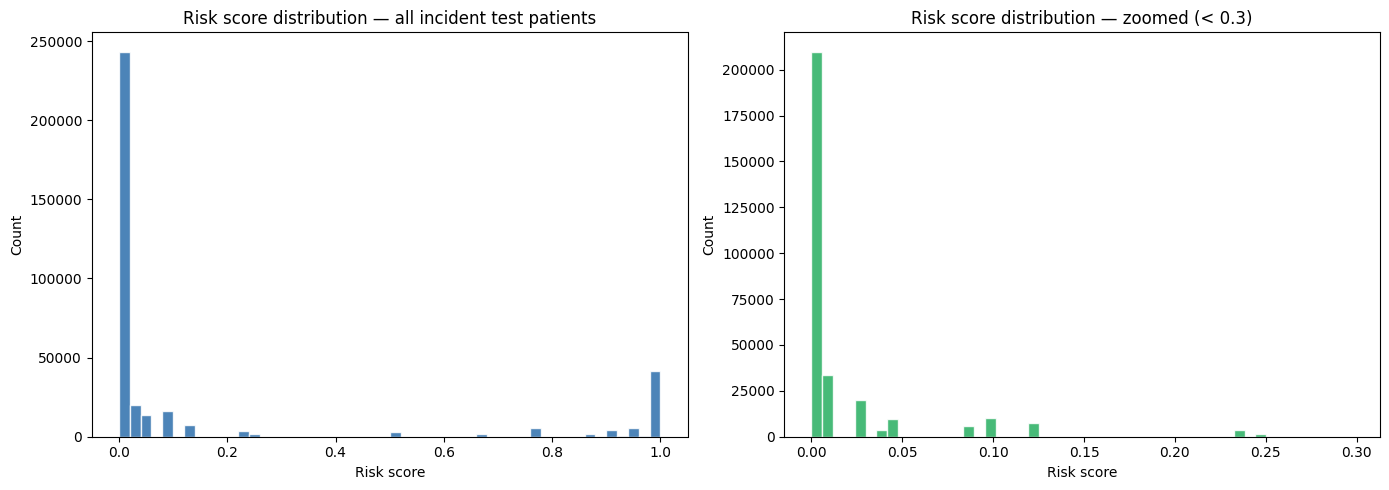

Risk score value counts (rounded to 1dp):
risk_score
0.0    276960
0.1     23877
0.2      5321
0.3         8
0.4        13
0.5      3402
0.6       471
0.7      1864
0.8      5706
0.9      6402
1.0     47636
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel A: Full distribution ────────────────────────────────
ax = axes[0]
ax.hist(test_inc['risk_score'], bins=50, color='#2C6FAC', alpha=0.85,
        edgecolor='white')
ax.set_xlabel('Risk score')
ax.set_ylabel('Count')
ax.set_title('Risk score distribution — all incident test patients')

# ── Panel B: Zoomed in (0 to 0.3) ────────────────────────────
ax = axes[1]
ax.hist(test_inc[test_inc['risk_score'] < 0.3]['risk_score'],
        bins=50, color='#27AE60', alpha=0.85, edgecolor='white')
ax.set_xlabel('Risk score')
ax.set_ylabel('Count')
ax.set_title('Risk score distribution — zoomed (< 0.3)')

plt.tight_layout()
plt.show()

# Print exact distribution
print("Risk score value counts (rounded to 1dp):")
print(test_inc['risk_score'].round(1).value_counts().sort_index())

Refitting calibrators with Platt scaling...
Fitted 11 Platt calibrators

Platt calibrated risk@12h stats:
  Mean   : 0.0528
  Median : 0.0064
  Std    : 0.1353


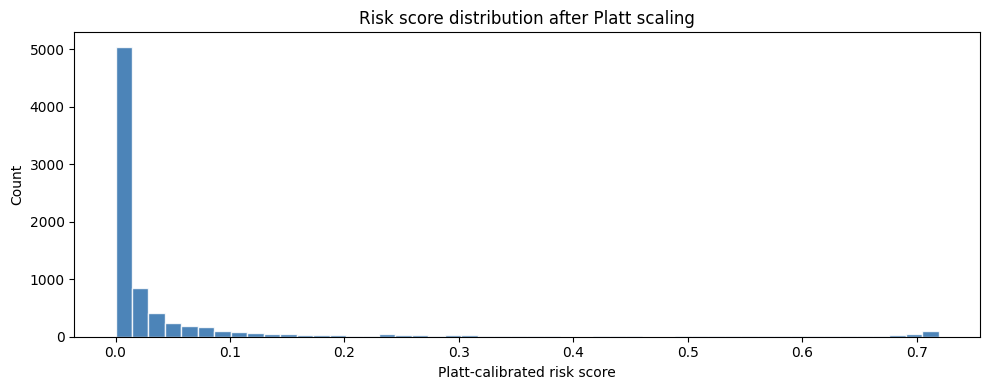


Saved -> dst_platt_calibrators.pkl ✓


In [ ]:
from sklearn.linear_model import LogisticRegression

print("Refitting calibrators with Platt scaling...")

# Get raw validation predictions
surv_val_raw, dur_val, evt_val = predict_survival(
    model, val_loader, device, time_cuts
)

# Fit Platt scaling calibrators at each time point
platt_calibrators = {}
for t_idx in np.arange(0, NUM_BINS, 4):
    true_label = ((evt_val==1) & (dur_val<=time_cuts[t_idx])).astype(float)
    pred_cif   = (1 - surv_val_raw[:, t_idx]).clip(0, 1).reshape(-1, 1)
    if true_label.sum() > 5 and (1-true_label).sum() > 5:
        lr = LogisticRegression(C=1.0)
        lr.fit(pred_cif, true_label)
        platt_calibrators[t_idx] = lr

print(f"Fitted {len(platt_calibrators)} Platt calibrators")

# Apply to test set
def apply_platt_calibration(surv, calibrators, num_bins):
    surv_cal      = surv.copy()
    cal_t_indices = sorted(calibrators.keys())
    for t_idx in cal_t_indices:
        lr       = calibrators[t_idx]
        pred_cif = (1 - surv_cal[:, t_idx]).clip(0, 1).reshape(-1, 1)
        cal_cif  = lr.predict_proba(pred_cif)[:, 1].clip(0, 1)
        surv_cal[:, t_idx] = 1 - cal_cif
    # Interpolate between calibrated points
    for t in range(num_bins):
        if t not in calibrators:
            lo = max([k for k in cal_t_indices if k <= t], default=None)
            hi = min([k for k in cal_t_indices if k >= t], default=None)
            if lo is not None and hi is not None and lo != hi:
                w = (t - lo) / (hi - lo)
                surv_cal[:, t] = (1-w)*surv_cal[:, lo] + w*surv_cal[:, hi]
            elif lo is not None:
                surv_cal[:, t] = surv_cal[:, lo]
            elif hi is not None:
                surv_cal[:, t] = surv_cal[:, hi]
    # Enforce monotone decreasing
    for t in range(1, num_bins):
        surv_cal[:, t] = np.minimum(surv_cal[:, t], surv_cal[:, t-1])
    return surv_cal

# Test on validation set
surv_test_raw, dur_test, evt_test = predict_survival(
    model, test_loader, device, time_cuts
)
surv_test_platt = apply_platt_calibration(surv_test_raw, platt_calibrators, NUM_BINS)

bin_12h  = int(np.clip(np.searchsorted(time_cuts, 12, 'right'), 0, NUM_BINS-1))
cal_risks = (1 - surv_test_platt[:, bin_12h]).clip(0, 1)

print(f"\nPlatt calibrated risk@12h stats:")
print(f"  Mean   : {cal_risks.mean():.4f}")
print(f"  Median : {np.median(cal_risks):.4f}")
print(f"  Std    : {cal_risks.std():.4f}")

# Plot distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.hist(cal_risks, bins=50, color='#2C6FAC', alpha=0.85, edgecolor='white')
plt.xlabel('Platt-calibrated risk score')
plt.ylabel('Count')
plt.title('Risk score distribution after Platt scaling')
plt.tight_layout()
plt.show()

# Save
joblib.dump(platt_calibrators, str(OUTPUT_DIR / 'dst_platt_calibrators.pkl'))
print('\nSaved -> dst_platt_calibrators.pkl ✓')

In [ ]:
# ── Rerun rolling inference with Platt calibration ────────────
print("Rerunning rolling inference with Platt calibration...")

results  = []
t_start  = time.time()

for batch_start in range(0, total_pairs, INFER_BATCH):
    batch     = eval_pairs[batch_start:batch_start + INFER_BATCH]
    x_seqs, x_statics, lengths, meta = [], [], [], []

    for stay_idx, stay_id, hour in batch:
        seq     = X_rich_proc[stay_idx, :hour, :]
        seq_len = len(seq)
        if seq_len == 0: continue
        x_seqs.append(torch.tensor(seq, dtype=torch.float32))
        x_statics.append(X_static_tensor[stay_idx])
        lengths.append(seq_len)
        meta.append((stay_id, hour, stay_split.get(stay_id, 'unknown')))

    if not x_seqs: continue

    max_len  = max(s.shape[0] for s in x_seqs)
    x_padded = torch.zeros(len(x_seqs), max_len, len(rich_feature_names))
    for i, seq in enumerate(x_seqs):
        x_padded[i, :seq.shape[0], :] = seq

    x_padded   = x_padded.to(device)
    x_static_b = torch.stack(x_statics).to(device)
    lengths_t  = torch.tensor(lengths, dtype=torch.long).to(device)

    with torch.no_grad():
        pmf = model(x_padded, x_static_b, lengths_t).cpu().numpy()

    surv     = 1 - np.cumsum(pmf, axis=1)
    surv_cal = apply_platt_calibration(surv, platt_calibrators, NUM_BINS)

    for i, (sid, hour, split) in enumerate(meta):
        risk_12h = float(np.clip(1 - surv_cal[i, bin_12h], 0.0, 1.0))
        tier     = get_alert_tier(risk_12h)
        label    = get_rolling_label(sid, hour)
        if label == -1: continue
        results.append({
            'stay_id'       : sid,
            'hour'          : hour,
            'risk_score'    : round(risk_12h, 4),
            'alert_tier'    : tier,
            'true_label_12h': label,
            'split'         : split,
        })

    if (batch_start // INFER_BATCH) % 100 == 0 and batch_start > 0:
        elapsed = time.time() - t_start
        pct     = batch_start / total_pairs
        eta     = (elapsed / max(pct, 1e-6)) * (1 - pct) / 60
        print(f'  {batch_start:>8,} / {total_pairs:,} '
              f'({pct:.1%}) | elapsed={elapsed/60:.1f}min | '
              f'ETA={eta:.1f}min', end='\r')

print(f'\n\nInference complete.')
print(f'Total time : {(time.time()-t_start)/60:.1f} minutes')
print(f'Results    : {len(results):,}')

rolling_df = pd.DataFrame(results)
rolling_df.to_csv(str(OUTPUT_DIR / 'dst_rolling_predictions.csv'), index=False)
rolling_df.to_csv(str(OUTPUT_DIR / 'rolling_predictions.csv'), index=False)
print('Saved ✓')

# Quick check
print('\nAlert tier distribution:')
for tier, count in rolling_df['alert_tier'].value_counts().items():
    print(f'  {tier:<12} : {count:>8,}  ({count/len(rolling_df):.2%})')

print('\nRisk score stats:')
print(f'  Mean   : {rolling_df["risk_score"].mean():.4f}')
print(f'  Median : {rolling_df["risk_score"].median():.4f}')

# Sample patient
test_roll = rolling_df[rolling_df['split'] == 'test']
auroc = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
print(f'\nTest AUROC : {auroc:.4f}')

sid = 30130376
onset = onset_lookup.get(sid)
sample = rolling_df[rolling_df['stay_id'] == sid].sort_values('hour')
print(f'\nSample stay {sid} onset={onset}h:')
print(sample[['hour','risk_score','alert_tier']].head(30).to_string(index=False))

Rerunning rolling inference with Platt calibration...
  2,457,600 / 2,500,579 (98.3%) | elapsed=6.0min | ETA=0.1min

Inference complete.
Total time : 6.1 minutes
Results    : 2,500,579
Saved ✓

Alert tier distribution:
  no_alert     : 2,132,455  (85.28%)
  high_risk    :  265,146  (10.60%)
  critical     :  102,978  (4.12%)

Risk score stats:
  Mean   : 0.1474
  Median : 0.0155

Test AUROC : 0.7957

Sample stay 30130376 onset=69h:
 hour  risk_score alert_tier
    1      0.5377  high_risk
    2      0.5437  high_risk
    3      0.5428  high_risk
    4      0.5379  high_risk
    5      0.5278  high_risk
    6      0.5075  high_risk
    7      0.4715   no_alert
    8      0.4164   no_alert
    9      0.3436   no_alert
   10      0.2668   no_alert
   11      0.2015   no_alert
   12      0.1533   no_alert
   13      0.1192   no_alert
   14      0.0948   no_alert
   15      0.0770   no_alert
   16      0.0635   no_alert
   17      0.0530   no_alert
   18      0.0447   no_alert
   19      0.

In [ ]:
# ── Save Platt calibrators as the primary calibrators ─────────
joblib.dump(platt_calibrators, str(OUTPUT_DIR / 'dst_calibrators.pkl'))

# ── Save updated survival curves ──────────────────────────────
surv_test_platt_saved = apply_platt_calibration(
    surv_test_raw, platt_calibrators, NUM_BINS
)
np.save(str(OUTPUT_DIR / 'dst_surv_cal.npy'), surv_test_platt_saved)
print('dst_calibrators.pkl updated to Platt scaling ✓')
print('dst_surv_cal.npy updated ✓')

# ── Final metrics ─────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, average_precision_score

test_roll     = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc = test_roll[~test_roll['stay_id'].isin(early_onset_stays)]

auroc_all = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
auprc_all = average_precision_score(test_roll['true_label_12h'], test_roll['risk_score'])
auroc_inc = roc_auc_score(test_inc['true_label_12h'],  test_inc['risk_score'])
auprc_inc = average_precision_score(test_inc['true_label_12h'],  test_inc['risk_score'])

print(f'\nFinal DST v2 (incident training + Platt calibration):')
print(f'  AUROC (all)      : {auroc_all:.4f}')
print(f'  AUPRC (all)      : {auprc_all:.4f}')
print(f'  AUROC (incident) : {auroc_inc:.4f}')
print(f'  AUPRC (incident) : {auprc_inc:.4f}')

print(f'\nAUROC by hour range (incident only):')
print(f"{'Hour range':>15} {'Stay-hours':>12} {'Positives':>10} {'AUROC':>8}")
print('-' * 50)
for lo, hi in [(1,4),(4,12),(12,24),(24,48),(48,96),(96,200)]:
    sub   = test_inc[(test_inc['hour']>=lo)&(test_inc['hour']<hi)]
    n_pos = sub['true_label_12h'].sum()
    if n_pos >= 10 and (len(sub)-n_pos) >= 10:
        a = roc_auc_score(sub['true_label_12h'], sub['risk_score'])
        print(f'  {lo:>3}h – {hi:>3}h : {len(sub):>10,}  {n_pos:>10,}  {a:>8.4f}')
    else:
        print(f'  {lo:>3}h – {hi:>3}h : insufficient events')

# ── Threshold analysis ────────────────────────────────────────
from sklearn.metrics import confusion_matrix, f1_score
print(f"\n{'Thresh':>8} {'Sens':>7} {'Spec':>7} {'PPV':>7} {'Alert%':>8} {'F1':>7}")
print("-" * 50)
for thresh in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    y_pred = (test_inc['risk_score'] >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        test_inc['true_label_12h'], y_pred, labels=[0,1]
    ).ravel()
    sens  = tp / (tp + fn + 1e-9)
    spec  = tn / (tn + fp + 1e-9)
    ppv   = tp / (tp + fp + 1e-9)
    f1    = 2*tp / (2*tp + fp + fn + 1e-9)
    alert = y_pred.mean()
    print(f"  {thresh:.2f}   {sens:>7.3f} {spec:>7.3f} {ppv:>7.3f} "
          f"{alert:>7.2%} {f1:>7.4f}")

dst_calibrators.pkl updated to Platt scaling ✓
dst_surv_cal.npy updated ✓

Final DST v2 (incident training + Platt calibration):
  AUROC (all)      : 0.7957
  AUPRC (all)      : 0.1690
  AUROC (incident) : 0.7169
  AUPRC (incident) : 0.1190

AUROC by hour range (incident only):
     Hour range   Stay-hours  Positives    AUROC
--------------------------------------------------
    1h –   4h :     23,661         932    0.8397
    4h –  12h :     61,489       2,144    0.8283
   12h –  24h :     76,677         890    0.7303
   24h –  48h :     91,875         893    0.6644
   48h –  96h :     75,437         755    0.6077
   96h – 200h :     42,521         490    0.6460

  Thresh    Sens    Spec     PPV   Alert%      F1
--------------------------------------------------
  0.10     0.615   0.720   0.035  28.56%  0.0669
  0.20     0.579   0.781   0.042  22.50%  0.0787
  0.30     0.553   0.821   0.049  18.51%  0.0901
  0.40     0.530   0.852   0.057  15.41%  0.1022
  0.50     0.501   0.878   0.

## Gradient SHAP

In [ ]:
# ── Cell 12: GradientSHAP (fixed) ────────────────────────────
import shap
print(f'SHAP version : {shap.__version__}')

print('Preparing SHAP background dataset...')
np.random.seed(42)
bg_indices = np.random.choice(len(train_ds), size=200, replace=False)

bg_seqs, bg_statics, bg_lengths = [], [], []
for idx in bg_indices:
    sample = train_ds[idx]
    bg_seqs.append(sample['x_seq'])
    bg_statics.append(sample['x_static'])
    bg_lengths.append(sample['length'])

max_bg_len  = max(s.shape[0] for s in bg_seqs)
bg_x_padded = torch.zeros(len(bg_seqs), max_bg_len, len(rich_feature_names))
for i, seq in enumerate(bg_seqs):
    bg_x_padded[i, :seq.shape[0], :] = seq
bg_x_static  = torch.stack(bg_statics).to(device)
bg_x_padded  = bg_x_padded.to(device)
print(f'  Background : {bg_x_static.shape}')


class StaticOnlyWrapper(nn.Module):
    """
    Wrapper that explains static features.
    x_seq_fixed shape: (1, T, vital_dim) — expanded to match batch size.
    """
    def __init__(self, model, x_seq_fixed, seq_len, max_seq_len):
        super().__init__()
        self.model       = model
        self.x_seq_fixed = x_seq_fixed   # (1, T, vital_dim)
        self.seq_len     = seq_len
        self.max_seq_len = max_seq_len

    def forward(self, x_static):
        B    = x_static.shape[0]
        # Expand fixed sequence to match batch size
        seq  = self.x_seq_fixed.expand(B, -1, -1)
        lens = torch.tensor([self.seq_len] * B,
                            dtype=torch.long, device=x_static.device)
        pmf  = self.model(seq, x_static, lens)
        surv = 1 - torch.cumsum(pmf, dim=1)
        return surv[:, bin_12h].unsqueeze(1)


print('\nSelecting test patients for SHAP...')
np.random.seed(42)
shap_stay_ids = np.random.choice(
    test_all['stay_id'].tolist(),
    size=min(500, len(test_all)),
    replace=False
)

shap_results = []
model.eval()
print(f'Computing SHAP for {len(shap_stay_ids)} patients...')
print('This takes ~10-20 minutes...')

for k, sid in enumerate(shap_stay_ids):
    if sid not in stay_to_idx:
        continue
    idx   = stay_to_idx[sid]
    onset = onset_lookup.get(sid, None)

    # Choose explanation hour
    if onset is not None and onset > 1:
        explain_hour = max(1, onset - 1)
    else:
        max_h        = min(max_hour_per_stay.get(sid, 1), MAX_HOURS - 1)
        explain_hour = max(1, max_h // 2)

    # Prepare sequence
    seq   = X_rich_proc[idx, :explain_hour, :]
    seq_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    # Pad/trim to max_bg_len so expand works cleanly
    if seq_t.shape[1] < max_bg_len:
        pad   = torch.zeros(1, max_bg_len - seq_t.shape[1],
                            len(rich_feature_names)).to(device)
        seq_t = torch.cat([seq_t, pad], dim=1)
    elif seq_t.shape[1] > max_bg_len:
        seq_t = seq_t[:, :max_bg_len, :]

    x_static_pt = X_static_tensor[idx].unsqueeze(0).to(device)

    # Build wrapper — passes seq_len not max_bg_len to mask correctly
    wrapper   = StaticOnlyWrapper(model, seq_t, explain_hour, max_bg_len)
    wrapper.eval()

    try:
        explainer = shap.GradientExplainer(wrapper, bg_x_static)
        shap_vals = explainer.shap_values(x_static_pt)
        if isinstance(shap_vals, list):
            sv = shap_vals[0].squeeze()
        else:
            sv = np.array(shap_vals).squeeze()
    except Exception as e:
        sv = np.zeros(len(feature_cols))

    # Risk score
    with torch.no_grad():
        seq_exp  = seq_t.expand(1, -1, -1)
        lens_t   = torch.tensor([explain_hour], dtype=torch.long).to(device)
        pmf      = model(seq_exp, x_static_pt, lens_t)
        surv     = 1 - torch.cumsum(pmf, dim=1)
        risk_cal = float(np.clip(1 - float(surv[0, bin_12h].cpu()), 0, 1))

    shap_results.append({
        'stay_id'    : int(sid),
        'hour'       : explain_hour,
        'risk_score' : round(risk_cal, 4),
        'shap_values': sv.tolist(),
        'event'      : int(onset is not None),
        'onset'      : onset if onset is not None else -1,
    })

    if (k + 1) % 50 == 0:
        print(f'  {k+1}/{len(shap_stay_ids)} patients done...', end='\r')

print(f'\nSHAP complete — {len(shap_results)} patients')

# ── Save ──────────────────────────────────────────────────────
shap_df     = pd.DataFrame(shap_results)
shap_matrix = np.array(shap_df['shap_values'].tolist())
np.save(str(OUTPUT_DIR / 'dst_shap_values.npy'),   shap_matrix)
np.save(str(OUTPUT_DIR / 'dst_shap_stay_ids.npy'),
        np.array(shap_df['stay_id'].tolist()))
shap_df.drop(columns=['shap_values']).to_csv(
    str(OUTPUT_DIR / 'dst_shap_meta.csv'), index=False
)
print(f'  dst_shap_values.npy  : {shap_matrix.shape} ✓')
print(f'  dst_shap_stay_ids.npy ✓')
print(f'  dst_shap_meta.csv    ✓')

# ── Global importance ─────────────────────────────────────────
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[::-1][:10]
print(f'\nTop 10 features by mean |SHAP|:')
print(f"{'Rank':>5} {'Feature':<35} {'Mean |SHAP|':>12} {'Direction':>10}")
print('-' * 65)
signed = shap_matrix.mean(axis=0)
for rank, fi in enumerate(top10_idx, 1):
    direction = 'Risk +' if signed[fi] > 0 else 'Protective'
    print(f'{rank:>5} {feature_cols[fi]:<35} '
          f'{mean_abs_shap[fi]:>12.5f} {direction:>10}')

SHAP version : 0.51.0
Preparing SHAP background dataset...
  Background : torch.Size([200, 127])

Selecting test patients for SHAP...
Computing SHAP for 500 patients...
This takes ~10-20 minutes...
  500/500 patients done...
SHAP complete — 500 patients
  dst_shap_values.npy  : (500, 127) ✓
  dst_shap_stay_ids.npy ✓
  dst_shap_meta.csv    ✓

Top 10 features by mean |SHAP|:
 Rank Feature                              Mean |SHAP|  Direction
-----------------------------------------------------------------
    1 spo2_missing_frac                        0.01056     Risk +
    2 uo_count                                 0.00888 Protective
    3 heart_rate_missing_frac                  0.00815     Risk +
    4 sofa_max_24h                             0.00772     Risk +
    5 spo2_slope                               0.00713     Risk +
    6 adm_type_surgical_same_day_admission      0.00581     Risk +
    7 anchor_age                               0.00567     Risk +
    8 heart_rate_max         

In [ ]:
# ── Cell 12: GradientSHAP — per patient per hour (DST v2) ─────
import shap
print(f'SHAP version : {shap.__version__}')

print('Preparing SHAP background dataset...')
np.random.seed(42)
bg_indices = np.random.choice(len(train_ds), size=200, replace=False)

bg_seqs, bg_statics, bg_lengths = [], [], []
for idx in bg_indices:
    sample = train_ds[idx]
    bg_seqs.append(sample['x_seq'])
    bg_statics.append(sample['x_static'])
    bg_lengths.append(sample['length'])

max_bg_len  = max(s.shape[0] for s in bg_seqs)
bg_x_padded = torch.zeros(len(bg_seqs), max_bg_len, len(rich_feature_names))
for i, seq in enumerate(bg_seqs):
    bg_x_padded[i, :seq.shape[0], :] = seq
bg_x_static  = torch.stack(bg_statics).to(device)
bg_x_padded  = bg_x_padded.to(device)
print(f'  Background : {bg_x_static.shape}')


class StaticOnlyWrapper(nn.Module):
    def __init__(self, model, x_seq_fixed, seq_len, max_seq_len):
        super().__init__()
        self.model       = model
        self.x_seq_fixed = x_seq_fixed
        self.seq_len     = seq_len
        self.max_seq_len = max_seq_len

    def forward(self, x_static):
        B    = x_static.shape[0]
        seq  = self.x_seq_fixed.expand(B, -1, -1)
        lens = torch.tensor([self.seq_len] * B,
                            dtype=torch.long, device=x_static.device)
        pmf  = self.model(seq, x_static, lens)
        # Use Platt calibrated risk score
        surv = 1 - torch.cumsum(pmf, dim=1)
        return surv[:, bin_12h].unsqueeze(1)


print('\nSelecting test patients for SHAP...')
np.random.seed(42)
shap_stay_ids = np.random.choice(
    test_all['stay_id'].tolist(),
    size=min(500, len(test_all)),
    replace=False
)

shap_results = []
model.eval()
print(f'Computing SHAP for {len(shap_stay_ids)} patients...')
print('This takes ~10-20 minutes...')

for k, sid in enumerate(shap_stay_ids):
    if sid not in stay_to_idx:
        continue
    idx   = stay_to_idx[sid]
    onset = onset_lookup.get(sid, None)

    if onset is not None and onset > 1:
        explain_hour = max(1, onset - 1)
    else:
        max_h        = min(max_hour_per_stay.get(sid, 1), MAX_HOURS - 1)
        explain_hour = max(1, max_h // 2)

    seq   = X_rich_proc[idx, :explain_hour, :]
    seq_t = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
    len_t = torch.tensor([explain_hour], dtype=torch.long).to(device)

    if seq_t.shape[1] < max_bg_len:
        pad   = torch.zeros(1, max_bg_len - seq_t.shape[1],
                            len(rich_feature_names)).to(device)
        seq_t = torch.cat([seq_t, pad], dim=1)
    elif seq_t.shape[1] > max_bg_len:
        seq_t = seq_t[:, :max_bg_len, :]

    x_static_pt = X_static_tensor[idx].unsqueeze(0).to(device)

    wrapper   = StaticOnlyWrapper(model, seq_t, explain_hour, max_bg_len)
    wrapper.eval()

    try:
        explainer = shap.GradientExplainer(wrapper, bg_x_static)
        shap_vals = explainer.shap_values(x_static_pt)
        if isinstance(shap_vals, list):
            sv = shap_vals[0].squeeze()
        else:
            sv = np.array(shap_vals).squeeze()
    except Exception as e:
        sv = np.zeros(len(feature_cols))

    with torch.no_grad():
        seq_exp  = seq_t.expand(1, -1, -1)
        pmf      = model(seq_exp, x_static_pt, len_t)
        surv_raw = 1 - torch.cumsum(pmf, dim=1)
        raw_risk = float(surv_raw[0, bin_12h].cpu())
        # Apply Platt calibration
        raw_cif  = np.array([[1 - raw_risk]])
        if bin_12h in platt_calibrators:
            cal_cif = platt_calibrators[bin_12h].predict_proba(raw_cif)[0, 1]
        else:
            cal_cif = 1 - raw_risk
        risk_cal = float(np.clip(cal_cif, 0, 1))

    shap_results.append({
        'stay_id'    : int(sid),
        'hour'       : explain_hour,
        'risk_score' : round(risk_cal, 4),
        'shap_values': sv.tolist(),
        'event'      : int(onset is not None),
        'onset'      : onset if onset is not None else -1,
    })

    if (k + 1) % 50 == 0:
        print(f'  {k+1}/{len(shap_stay_ids)} patients done...', end='\r')

print(f'\nSHAP complete — {len(shap_results)} patients')

shap_df     = pd.DataFrame(shap_results)
shap_matrix = np.array(shap_df['shap_values'].tolist())
np.save(str(OUTPUT_DIR / 'dst_shap_values.npy'),   shap_matrix)
np.save(str(OUTPUT_DIR / 'dst_shap_stay_ids.npy'),
        np.array(shap_df['stay_id'].tolist()))
shap_df.drop(columns=['shap_values']).to_csv(
    str(OUTPUT_DIR / 'dst_shap_meta.csv'), index=False
)
print(f'  dst_shap_values.npy  : {shap_matrix.shape} ✓')
print(f'  dst_shap_stay_ids.npy ✓')
print(f'  dst_shap_meta.csv    ✓')

mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
top10_idx     = np.argsort(mean_abs_shap)[::-1][:10]
signed        = shap_matrix.mean(axis=0)
print(f'\nTop 10 features by mean |SHAP|:')
print(f"{'Rank':>5} {'Feature':<35} {'Mean |SHAP|':>12} {'Direction':>10}")
print('-' * 65)
for rank, fi in enumerate(top10_idx, 1):
    direction = 'Risk +' if signed[fi] > 0 else 'Protective'
    print(f'{rank:>5} {feature_cols[fi]:<35} '
          f'{mean_abs_shap[fi]:>12.5f} {direction:>10}')

SHAP version : 0.51.0
Preparing SHAP background dataset...
  Background : torch.Size([200, 127])

Selecting test patients for SHAP...
Computing SHAP for 500 patients...
This takes ~10-20 minutes...
  500/500 patients done...
SHAP complete — 500 patients
  dst_shap_values.npy  : (500, 127) ✓
  dst_shap_stay_ids.npy ✓
  dst_shap_meta.csv    ✓

Top 10 features by mean |SHAP|:
 Rank Feature                              Mean |SHAP|  Direction
-----------------------------------------------------------------
    1 spo2_missing_frac                        0.01207     Risk +
    2 anchor_age                               0.00920     Risk +
    3 heart_rate_missing_frac                  0.00872     Risk +
    4 adm_type_surgical_same_day_admission      0.00863 Protective
    5 spo2_slope                               0.00757 Protective
    6 uo_count                                 0.00684     Risk +
    7 sofa_max_24h                             0.00561     Risk +
    8 uo_min_hourly          

In [ ]:
# ── Cell 13: Save all files needed by the UI backend ──────────
print('Saving all UI backend files...')
print('='*55)

from sklearn.metrics import confusion_matrix, f1_score

test_roll  = rolling_df[rolling_df['split'] == 'test'].copy()
early_onset_stays = set(
    sid for sid, onset in onset_lookup.items() if onset <= 4
)
test_inc   = test_roll[~test_roll['stay_id'].isin(early_onset_stays)]

auroc_all  = roc_auc_score(test_roll['true_label_12h'], test_roll['risk_score'])
auprc_all  = average_precision_score(test_roll['true_label_12h'], test_roll['risk_score'])
auroc_inc  = roc_auc_score(test_inc['true_label_12h'],  test_inc['risk_score'])
auprc_inc  = average_precision_score(test_inc['true_label_12h'],  test_inc['risk_score'])

y_true = test_roll['true_label_12h'].values
y_pred = (test_roll['risk_score'] >= 0.70).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

lead_times = []
for sid in test_roll[test_roll['true_label_12h']==1]['stay_id'].unique():
    onset  = onset_lookup.get(sid)
    if onset is None or onset <= 4: continue
    stay   = test_roll[test_roll['stay_id']==sid].sort_values('hour')
    alerts = stay[stay['risk_score'] >= 0.70]['hour']
    if len(alerts) > 0:
        lt = onset - alerts.min()
        if lt >= 0:
            lead_times.append(lt)
lead_times = np.array(lead_times)

# Recompute C-index and IBS with Platt calibrated survival curves
surv_platt = apply_platt_calibration(surv_test_raw, platt_calibrators, NUM_BINS)
cindex_cal = compute_cindex(surv_platt, dur_test, evt_test, time_cuts)
ibs_cal    = compute_ibs(surv_platt, dur_test, evt_test, time_cuts)

dst_inc_mask = (evt_test == 0) | (dur_test > 4)
cindex_inc   = compute_cindex(
    surv_platt[dst_inc_mask], dur_test[dst_inc_mask],
    evt_test[dst_inc_mask], time_cuts
)
ibs_inc = compute_ibs(
    surv_platt[dst_inc_mask], dur_test[dst_inc_mask],
    evt_test[dst_inc_mask], time_cuts
)

dst_results = {
    'model'              : 'DynamicSurvivalTransformer',
    'version'            : '2.0',
    'training'           : 'Incident sepsis only (onset > 4h)',
    'calibration'        : 'Platt scaling',
    'auroc_all'          : round(float(auroc_all),  4),
    'auprc_all'          : round(float(auprc_all),  4),
    'auroc_incident'     : round(float(auroc_inc),  4),
    'auprc_incident'     : round(float(auprc_inc),  4),
    'cindex'             : round(float(cindex_cal),  4),
    'ibs'                : round(float(ibs_cal),     4),
    'cindex_incident'    : round(float(cindex_inc),  4),
    'ibs_incident'       : round(float(ibs_inc),     4),
    'threshold_critical' : 0.70,
    'threshold_high_risk': 0.50,
    'sensitivity'        : round(float(tp/(tp+fn+1e-9)), 4),
    'specificity'        : round(float(tn/(tn+fp+1e-9)), 4),
    'ppv'                : round(float(tp/(tp+fp+1e-9)), 4),
    'npv'                : round(float(tn/(tn+fn+1e-9)), 4),
    'f1'                 : round(float(f1_score(y_true, y_pred)), 4),
    'alert_rate_critical': round(float(y_pred.mean()), 4),
    'mean_lead_time_h'   : round(float(lead_times.mean()), 1) if len(lead_times) > 0 else None,
    'median_lead_time_h' : round(float(np.median(lead_times)), 1) if len(lead_times) > 0 else None,
    'pct_ge_6h_lead'     : round(float((lead_times>=6).mean()), 4) if len(lead_times) > 0 else None,
    'pct_ge_12h_lead'    : round(float((lead_times>=12).mean()), 4) if len(lead_times) > 0 else None,
    'n_shap_patients'    : len(shap_results),
    'shap_top_features'  : [feature_cols[i] for i in top10_idx[:10]],
}

with open(OUTPUT_DIR / 'dst_results.json', 'w') as f:
    json.dump(dst_results, f, indent=2)
print('  dst_results.json         ✓')

with open(OUTPUT_DIR / 'dst_feature_cols.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
with open(OUTPUT_DIR / 'dst_rich_feature_names.txt', 'w') as f:
    f.write('\n'.join(rich_feature_names))
print('  dst_feature_cols.txt     ✓')
print('  dst_rich_feature_names.txt ✓')

# Save Platt calibrators explicitly
joblib.dump(platt_calibrators, str(OUTPUT_DIR / 'dst_calibrators.pkl'))
np.save(str(OUTPUT_DIR / 'dst_surv_cal.npy'), surv_platt)
print('  dst_calibrators.pkl      ✓ (Platt scaling)')
print('  dst_surv_cal.npy         ✓ (Platt calibrated)')

print('\nComplete file checklist:')
files = [
    ('dst_best.pt',                  'Model weights'),
    ('dst_calibrators.pkl',          'Platt scaling calibrators'),
    ('dst_scaler.pkl',               'Static feature scaler'),
    ('dst_winsor_lo.npy',            'Static winsor lower bounds'),
    ('dst_winsor_hi.npy',            'Static winsor upper bounds'),
    ('dst_vital_winsor_lo.npy',      'Vital winsor lower bounds'),
    ('dst_vital_winsor_hi.npy',      'Vital winsor upper bounds'),
    ('dst_rolling_predictions.csv',  'Rolling predictions'),
    ('dst_shap_values.npy',          'SHAP values (500 patients)'),
    ('dst_shap_stay_ids.npy',        'SHAP patient IDs'),
    ('dst_shap_meta.csv',            'SHAP metadata'),
    ('dst_results.json',             'Results summary'),
    ('dst_feature_cols.txt',         'Static feature names'),
    ('dst_rich_feature_names.txt',   'Vital feature names'),
    ('dst_surv_raw.npy',             'Raw survival curves'),
    ('dst_surv_cal.npy',             'Platt calibrated survival curves'),
    ('dst_dur_test.npy',             'Test durations'),
    ('dst_evt_test.npy',             'Test events'),
    ('dst_training_history.csv',     'Training history'),
]

all_good = True
for fname, desc in files:
    exists = (OUTPUT_DIR / fname).exists()
    if not exists: all_good = False
    status = '✓' if exists else '✗ MISSING'
    print(f'  {status:<10} {fname:<40} {desc}')

print('\n' + '='*55)
print('DST v2 FINAL RESULTS SUMMARY')
print('='*55)
print(f'  Training        : Incident sepsis only (onset > 4h)')
print(f'  Calibration     : Platt scaling')
print(f'  C-index (all)   : {dst_results["cindex"]:.4f}')
print(f'  C-index (inc)   : {dst_results["cindex_incident"]:.4f}')
print(f'  IBS (all)       : {dst_results["ibs"]:.4f}')
print(f'  AUROC (all)     : {dst_results["auroc_all"]:.4f}')
print(f'  AUROC (inc)     : {dst_results["auroc_incident"]:.4f}')
print(f'  AUPRC (all)     : {dst_results["auprc_all"]:.4f}')
print(f'  Sensitivity@0.70: {dst_results["sensitivity"]:.4f}')
print(f'  Specificity@0.70: {dst_results["specificity"]:.4f}')
print(f'  PPV @0.70       : {dst_results["ppv"]:.4f}')
print(f'  Mean lead time  : {dst_results["mean_lead_time_h"]}h')
print(f'  Median lead time: {dst_results["median_lead_time_h"]}h')
print(f'  ≥6h warning     : {dst_results["pct_ge_6h_lead"]:.1%}')
print('='*55)
if all_good:
    print('\n03f complete ✓')
    print('All files saved — ready for 03d and 04 updates')
else:
    print('\n⚠ Some files missing — check above')

Saving all UI backend files...
  dst_results.json         ✓
  dst_feature_cols.txt     ✓
  dst_rich_feature_names.txt ✓
  dst_calibrators.pkl      ✓ (Platt scaling)
  dst_surv_cal.npy         ✓ (Platt calibrated)

Complete file checklist:
  ✓          dst_best.pt                              Model weights
  ✓          dst_calibrators.pkl                      Platt scaling calibrators
  ✓          dst_scaler.pkl                           Static feature scaler
  ✓          dst_winsor_lo.npy                        Static winsor lower bounds
  ✓          dst_winsor_hi.npy                        Static winsor upper bounds
  ✓          dst_vital_winsor_lo.npy                  Vital winsor lower bounds
  ✓          dst_vital_winsor_hi.npy                  Vital winsor upper bounds
  ✓          dst_rolling_predictions.csv              Rolling predictions
  ✓          dst_shap_values.npy                      SHAP values (500 patients)
  ✓          dst_shap_stay_ids.npy                    SHAP p